In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from building_models.training_models.paired_delta_analysis import *

### Paired delta analysis and methodological decision ranking

This notebook performs a paired comparative analysis of the model-training results prepared in the previous analysis stage. The input file, `results_prepared_for_analysis.csv`, is generated by the exploratory analysis notebook.

The analysis quantifies how methodological decisions affect predictive performance by calculating paired differences between candidate configurations and predefined reference conditions. For each comparison, the delta is defined as:


ΔM = candidate performance - baseline performance


Positive delta values indicate that the candidate configuration improves performance relative to the reference condition, whereas negative values indicate a performance loss. The complementary loss measure is calculated as the baseline performance minus the candidate performance.

The notebook evaluates the effects of partition strategy, redundancy-reduction strategy, numerical representation, feature normalization, and classification algorithm. The main reference conditions include random partitioning, no redundancy reduction, one-hot encoding, and no feature normalization. Comparisons are performed while preserving the remaining experimental variables whenever possible, including algorithm, hyperparameter configuration, scaler, seed, representation, and reduction level.

The paired results are used to construct decision rankings that prioritize configurations with low performance loss, stable behavior across seeds and experimental conditions, sufficient paired observations, and competitive absolute performance. F1-score is used as the primary ranking metric, while Matthews correlation coefficient (MCC) is used as a secondary criterion.

The notebook also examines realistic methodological combinations, algorithm robustness, seed coverage, enriched patterns among top-ranked configurations, confidence intervals obtained through bootstrap resampling, direct paired comparisons between leading configurations, and non-inferiority relative to reference scenarios.

Figures, ranking tables, paired-delta datasets, seed-coverage summaries, and statistical comparison outputs are saved in the `delta_analysis_outputs` directory for reporting and downstream interpretation.

In [2]:
folder_path = "../../analysed_training"
df = (
    pd.read_csv(
        Path(folder_path) / "results_prepared_for_analysis.csv"
    )
    .copy()
)

METRICS = [m for m in METRICS if m in df.columns]
df.head()

,experiment_dir,representation_clean,reduction_strategy_clean,reduced_by,split_space_clean,reduction_level,reduction_percentile,homology_threshold,algorithm,partition_strategy,...,f1_test_n,mcc_test_mean,mcc_test_std,mcc_test_n,result_origin,representation_label,reduced_by_label,partition_label,reduction_label,reduction_level_label
0,ankh2_ext1_no_reduced,ankh2_ext1,no_reduction,none,ankh2_ext1,no_level,not_applicable,not_applicable,DecisionTreeClassifier,distance_aware_kfold,...,5,0.559384,0.146547,5,historical,Ankh2,none,Distance-aware,No reduction,no_level
1,ankh2_ext1_no_reduced,ankh2_ext1,no_reduction,none,ankh2_ext1,no_level,not_applicable,not_applicable,DecisionTreeClassifier,distance_aware_kfold,...,5,0.604498,0.257667,5,historical,Ankh2,none,Distance-aware,No reduction,no_level
2,ankh2_ext1_no_reduced,ankh2_ext1,no_reduction,none,ankh2_ext1,no_level,not_applicable,not_applicable,DecisionTreeClassifier,distance_aware_kfold,...,5,0.606285,0.224870,5,historical,Ankh2,none,Distance-aware,No reduction,no_level
3,ankh2_ext1_no_reduced,ankh2_ext1,no_reduction,none,ankh2_ext1,no_level,not_applicable,not_applicable,DecisionTreeClassifier,distance_aware_kfold,...,5,0.583536,0.263036,5,historical,Ankh2,none,Distance-aware,No reduction,no_level
4,ankh2_ext1_no_reduced,ankh2_ext1,no_reduction,none,ankh2_ext1,no_level,not_applicable,not_applicable,DecisionTreeClassifier,distance_aware_kfold,...,5,0.579836,0.284004,5,historical,Ankh2,none,Distance-aware,No reduction,no_level


- Separate baseline 1 and 2

In [3]:
# Convert key columns to strings to avoid NaN problems
df["representation_label_str"] = df["representation_label"].astype(str)
df["representation_clean_str"] = df["representation_clean"].astype(str)
df["reduction_label_str"] = df["reduction_label"].astype(str)
df["reduction_strategy_clean_str"] = df["reduction_strategy_clean"].astype(str)
df["partition_label_str"] = df["partition_label"].astype(str)

# Detect One-hot
df["is_onehot"] = (
    df["representation_label_str"].str.lower().str.contains("one")
    |
    df["representation_clean_str"].str.lower().str.contains("one")
)

# Detect No reduction
df["is_no_reduction"] = (
    df["reduction_label_str"].str.lower().eq("no reduction")
    |
    df["reduction_strategy_clean_str"].str.lower().str.contains("no")
)

# Detect embeddings
df["is_embedding"] = ~df["is_onehot"]
df["baseline_context"] = df.apply(assign_baseline_context, axis=1)

print(df["baseline_context"].value_counts(dropna=False))

baseline_context
Other                            1923120
B2: Embeddings + No reduction      34560
B1: One-hot + No reduction          3840
Name: count, dtype: int64


- Build delta_partition list

In [4]:
delta_partition_list = []

for context_name in [
    "B1: One-hot + No reduction",
    "B2: Embeddings + No reduction",
]:
    context_filter = df["baseline_context"].eq(context_name)

    baseline_filter = (
        context_filter
        &
        df["partition_label"].astype(str).eq(BASELINE_PARTITION)
    )

    candidate_filter = (
        context_filter
        &
        df["partition_label"].astype(str).isin(CANDIDATE_PARTITIONS)
    )

    delta_context = compute_paired_delta(
        dataframe=df,
        baseline_filter=baseline_filter,
        candidate_filter=candidate_filter,
        match_cols=partition_match_cols,
        candidate_context_cols=partition_context_cols,
        metric_cols=METRICS,
        comparison_name=f"Partition effect relative to Random | {context_name}",
    )

    delta_partition_list.append(delta_context)

delta_partition = pd.concat(delta_partition_list, ignore_index=True)

print("delta_partition shape:", delta_partition.shape)
display(delta_partition.head())

delta_partition shape: (25920, 67)


,baseline_context,representation_clean,algorithm,scaler,cfg_idx,seed,reduction_strategy_clean,reduction_label,reduced_by,reduction_level,...,delta__recall_test_mean,loss__recall_test_mean,retention__recall_test_mean,delta__f1_test_mean,loss__f1_test_mean,retention__f1_test_mean,delta__mcc_test_mean,loss__mcc_test_mean,retention__mcc_test_mean,comparison_name
0,B1: One-hot + No reduction,onehot,DecisionTreeClassifier,none,0,113,no_reduction,No reduction,none,no_level,...,-0.331092,0.331092,0.468349,-0.301206,0.301206,0.517469,-0.324653,0.324653,0.358101,Partition effect relative to Random | B1: One-...
1,B1: One-hot + No reduction,onehot,DecisionTreeClassifier,none,0,113,no_reduction,No reduction,none,no_level,...,-0.363196,0.363196,0.416798,-0.331520,0.331520,0.468906,-0.362523,0.362523,0.283226,Partition effect relative to Random | B1: One-...
2,B1: One-hot + No reduction,onehot,DecisionTreeClassifier,none,0,113,no_reduction,No reduction,none,no_level,...,0.005950,-0.005950,1.009554,-0.014360,0.014360,0.976995,-0.024067,0.024067,0.952415,Partition effect relative to Random | B1: One-...
3,B1: One-hot + No reduction,onehot,DecisionTreeClassifier,none,0,2510,no_reduction,No reduction,none,no_level,...,-0.343706,0.343706,0.472669,-0.304811,0.304811,0.515795,-0.324456,0.324456,0.360532,Partition effect relative to Random | B1: One-...
4,B1: One-hot + No reduction,onehot,DecisionTreeClassifier,none,0,2510,no_reduction,No reduction,none,no_level,...,-0.358598,0.358598,0.449820,-0.316061,0.316061,0.497925,-0.337651,0.337651,0.334526,Partition effect relative to Random | B1: One-...


- Construct the delta_reduction list

In [5]:
baseline_filter_reduction = (
    df["reduction_label"].astype(str).eq(BASELINE_REDUCTION)
)

candidate_filter_reduction = (
    df["reduction_label"].astype(str).isin(CANDIDATE_REDUCTIONS)
)

delta_reduction = compute_paired_delta(
    dataframe=df,
    baseline_filter=baseline_filter_reduction,
    candidate_filter=candidate_filter_reduction,
    match_cols=reduction_match_cols,
    candidate_context_cols=reduction_context_cols,
    metric_cols=METRICS,
    comparison_name="Reduction effect relative to No reduction",
)

print("delta_reduction shape:", delta_reduction.shape)
display(delta_reduction.head())

delta_reduction shape: (1889184, 66)


,representation_clean,algorithm,partition_strategy,partition_label,scaler,cfg_idx,seed,representation_label,reduction_label,reduced_by,...,delta__recall_test_mean,loss__recall_test_mean,retention__recall_test_mean,delta__f1_test_mean,loss__f1_test_mean,retention__f1_test_mean,delta__mcc_test_mean,loss__mcc_test_mean,retention__mcc_test_mean,comparison_name
0,ankh2_ext1,DecisionTreeClassifier,distance_aware_kfold,Distance-aware,none,0,113,Ankh2,Distance reduction,ankh2_ext1,...,-0.630750,0.630750,0.000000,-0.632419,0.632419,0.000000,-0.603954,0.603954,-0.079678,Reduction effect relative to No reduction
1,ankh2_ext1,DecisionTreeClassifier,distance_aware_kfold,Distance-aware,none,0,113,Ankh2,Distance reduction,ankh2_ext1,...,-0.530750,0.530750,0.158541,-0.558694,0.558694,0.116577,-0.525675,0.525675,0.060260,Reduction effect relative to No reduction
2,ankh2_ext1,DecisionTreeClassifier,distance_aware_kfold,Distance-aware,none,0,113,Ankh2,Distance reduction,ankh2_ext1,...,-0.561306,0.561306,0.110098,-0.577035,0.577035,0.087576,-0.547089,0.547089,0.021979,Reduction effect relative to No reduction
3,ankh2_ext1,DecisionTreeClassifier,distance_aware_kfold,Distance-aware,none,0,113,Ankh2,Distance reduction,ankh2_ext1,...,-0.583315,0.583315,0.075205,-0.578086,0.578086,0.085913,-0.548158,0.548158,0.020069,Reduction effect relative to No reduction
4,ankh2_ext1,DecisionTreeClassifier,distance_aware_kfold,Distance-aware,none,0,113,Ankh2,Distance reduction,ankh2_ext1,...,-0.494301,0.494301,0.216328,-0.533460,0.533460,0.156478,-0.487886,0.487886,0.127816,Reduction effect relative to No reduction


- Create the delta_rep_vs_onehot list

In [6]:
baseline_filter_rep = (
    df["is_onehot"] &
    df["is_no_reduction"] &
    df["partition_label"].astype(str).isin(REP_PARTITIONS_TO_COMPARE)
)

candidate_filter_rep = (
    df["is_embedding"] &
    df["is_no_reduction"] &
    df["partition_label"].astype(str).isin(REP_PARTITIONS_TO_COMPARE)
)

delta_rep_vs_onehot = compute_paired_delta(
    dataframe=df,
    baseline_filter=baseline_filter_rep,
    candidate_filter=candidate_filter_rep,
    match_cols=representation_match_cols,
    candidate_context_cols=representation_context_cols,
    metric_cols=METRICS,
    comparison_name="Embedding representation effect relative to One-hot",
)

print("delta_rep_vs_onehot shape:", delta_rep_vs_onehot.shape)

display(
    delta_rep_vs_onehot
    .groupby(["partition_label", "representation_label"], dropna=False)
    .size()
    .reset_index(name="n_pairs")
    .sort_values(["partition_label", "representation_label"])
)

delta_rep_vs_onehot shape: (17280, 59)


,partition_label,representation_label,n_pairs
0,Distance-aware,Ankh2,960
1,Distance-aware,ESM2-8M,960
2,Distance-aware,ESMC-300M,960
3,Distance-aware,Mistral-Prot,960
4,Distance-aware,ProtBERT,960
5,Distance-aware,ProtT5,960
6,Random,Ankh2,960
7,Random,ESM2-8M,960
8,Random,ESMC-300M,960
9,Random,Mistral-Prot,960


- Question 1. Which partition best preserves performance compared to Random?

In [7]:
R1_group_cols = [
    "baseline_context",
    "partition_label",
]

R1_partition_ranking = make_decision_ranking(
    delta_df=delta_partition,
    group_cols=R1_group_cols,
    primary_metric=PRIMARY_METRIC,
    secondary_metric=SECONDARY_METRIC,
    rank_context_cols=[
        "baseline_context",
    ],
    performance_filter="median",
    min_pairs=5,
)

print("R1_partition_ranking shape:", R1_partition_ranking.shape)
display(R1_partition_ranking)

R1_partition_ranking shape: (5, 32)


,baseline_context,partition_label,n_pairs,n_seeds,baseline_mean__mcc_val_mean,candidate_mean__mcc_val_mean,delta_mean__mcc_val_mean,delta_median__mcc_val_mean,delta_std__mcc_val_mean,loss_mean__mcc_val_mean,...,retention_mean__f1_val_mean,prop_negative_delta__f1_val_mean,prop_delta_below_minus_005__f1_val_mean,prop_delta_below_minus_010__f1_val_mean,performance_threshold,passes_min_pairs,passes_performance_filter,rank_by_lowest_loss,decision_rank,decision_class
0,B1: One-hot + No reduction,Distance-aware normalized,960,30,0.582555,0.603233,0.020678,0.019414,0.026263,-0.020678,...,1.040142,0.180208,0.001042,0.000000,0.603150,True,True,1,1,Recommended
1,B1: One-hot + No reduction,Distance-aware,960,30,0.582555,0.603150,0.020595,0.019907,0.026122,-0.020595,...,1.040027,0.189583,0.001042,0.000000,0.603150,True,True,2,2,Recommended
2,B1: One-hot + No reduction,Stratified,960,30,0.582555,0.583056,0.000501,0.000901,0.026725,-0.000501,...,1.002521,0.470833,0.026042,0.000000,0.603150,True,False,3,<NA>,Low performance or insufficient evidence
3,B2: Embeddings + No reduction,Distance-aware,11520,30,0.715099,0.712563,-0.002535,-0.001228,0.029845,0.002535,...,0.997785,0.535677,0.033420,0.002517,0.711969,True,True,1,1,Recommended
4,B2: Embeddings + No reduction,Stratified,11520,30,0.715099,0.711375,-0.003724,-0.002545,0.021663,0.003724,...,0.995336,0.547656,0.011024,0.000000,0.711969,True,False,2,<NA>,Low performance or insufficient evidence


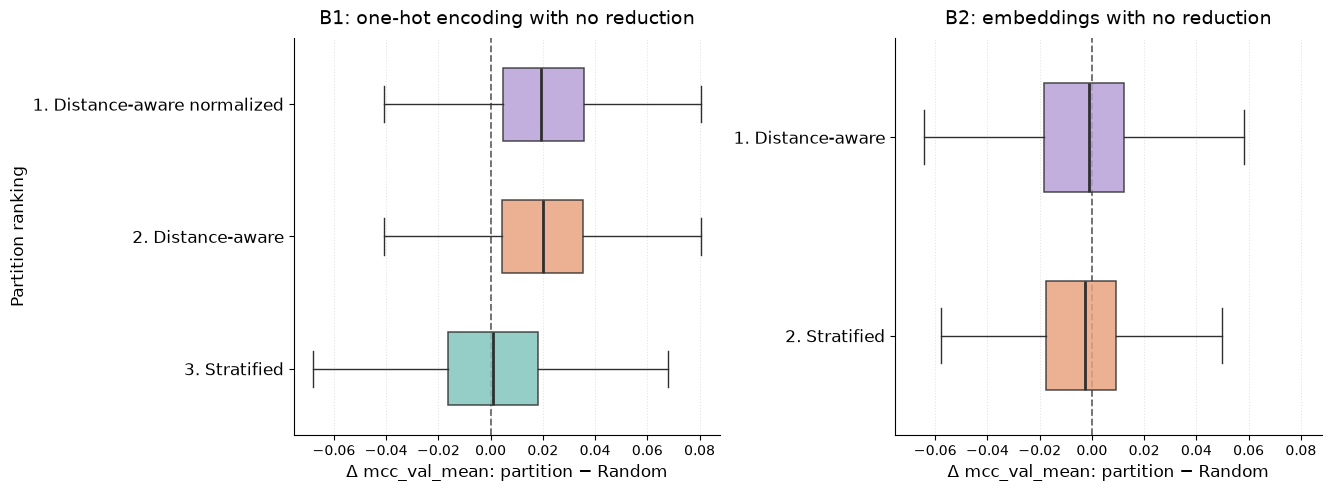

In [8]:
plot_R1_partition_ranking_boxplot_pretty(
    delta_partition=delta_partition,
    R1_partition_ranking=R1_partition_ranking,
    metric=PRIMARY_METRIC,
    output_file="R1_partition_ranking_boxplot_pretty.png",
)

- Question 2: For a given representation and partition, which reduction strategy best preserves performance compared to No reduction?

In [9]:
delta_reduction_rank = delta_reduction.copy()

delta_reduction_rank["reduced_by_label_clean"] = (
    delta_reduction_rank["reduced_by_label"]
    .astype(str)
)

delta_reduction_rank.loc[
    delta_reduction_rank["reduction_label"].astype(str).eq("Homology reduction"),
    "reduced_by_label_clean"
] = "homology"

display(
    delta_reduction_rank[
        [
            "representation_label",
            "partition_label",
            "reduction_label",
            "reduced_by_label",
            "reduced_by_label_clean",
            "reduction_level_label",
        ]
    ].head()
)

,representation_label,partition_label,reduction_label,reduced_by_label,reduced_by_label_clean,reduction_level_label
0,Ankh2,Distance-aware,Distance reduction,Ankh2,Ankh2,p90_0
1,Ankh2,Distance-aware,Distance reduction,Ankh2,Ankh2,p95_0
2,Ankh2,Distance-aware,Distance reduction,Ankh2,Ankh2,p97_0
3,Ankh2,Distance-aware,Distance reduction,Ankh2,Ankh2,p98_0
4,Ankh2,Distance-aware,Distance reduction,Ankh2,Ankh2,p99_0


In [10]:
R2_group_cols = [
    "representation_label",
    "partition_label",
    "reduction_label",
    "reduced_by_label_clean",
]

R2_reduction_ranking = make_decision_ranking(
    delta_df=delta_reduction_rank,
    group_cols=R2_group_cols,
    primary_metric=PRIMARY_METRIC,
    secondary_metric=SECONDARY_METRIC,
    rank_context_cols=[
        "partition_label",
    ],
    performance_filter="median",
    min_pairs=5,
)

print("R2_reduction_ranking shape:", R2_reduction_ranking.shape)
display(R2_reduction_ranking.head())

R2_reduction_ranking shape: (154, 34)


,representation_label,partition_label,reduction_label,reduced_by_label_clean,n_pairs,n_seeds,baseline_mean__mcc_val_mean,candidate_mean__mcc_val_mean,delta_mean__mcc_val_mean,delta_median__mcc_val_mean,...,retention_mean__f1_val_mean,prop_negative_delta__f1_val_mean,prop_delta_below_minus_005__f1_val_mean,prop_delta_below_minus_010__f1_val_mean,performance_threshold,passes_min_pairs,passes_performance_filter,rank_by_lowest_loss,decision_rank,decision_class
0,Ankh2,Distance-aware,Distance reduction,Mistral-Prot,16704,30,0.804243,0.666098,-0.138145,-0.066497,...,0.800435,0.897809,0.641583,0.391343,0.238627,True,True,1,1,Recommended
1,ProtT5,Distance-aware,Distance reduction,Mistral-Prot,16704,30,0.826918,0.663049,-0.163869,-0.084776,...,0.787797,0.976413,0.735034,0.466595,0.238627,True,True,2,2,Recommended
2,ESM2-8M,Distance-aware,Distance reduction,Mistral-Prot,16704,30,0.801880,0.624928,-0.176951,-0.090815,...,0.756682,0.982040,0.784722,0.493954,0.238627,True,True,3,3,Recommended
3,One-hot,Distance-aware,Distance reduction,Mistral-Prot,7680,30,0.603150,0.392047,-0.211103,-0.175698,...,0.586702,0.999740,0.993099,0.922786,0.238627,True,True,4,4,Recommended
4,ESMC-300M,Distance-aware,Distance reduction,Mistral-Prot,16704,30,0.684087,0.467167,-0.216920,-0.140273,...,0.646108,0.949234,0.896252,0.710189,0.238627,True,True,5,5,Recommended


In [11]:
R2_cols_to_show = [
    c for c in R2_cols_to_show
    if c in R2_reduction_ranking.columns
]

display(
    R2_reduction_ranking[R2_cols_to_show]
    .sort_values(
        [
            "representation_label",
            "partition_label",
            "rank_by_lowest_loss",
        ],
        na_position="last",
    )
)

,representation_label,partition_label,reduction_label,reduced_by_label_clean,n_pairs,n_seeds,baseline_mean__mcc_val_mean,candidate_mean__mcc_val_mean,delta_mean__mcc_val_mean,delta_median__mcc_val_mean,delta_std__mcc_val_mean,loss_mean__mcc_val_mean,retention_mean__mcc_val_mean,prop_negative_delta__mcc_val_mean,prop_delta_below_minus_005__mcc_val_mean,prop_delta_below_minus_010__mcc_val_mean,rank_by_lowest_loss,decision_rank,decision_class
0,Ankh2,Distance-aware,Distance reduction,Mistral-Prot,16704,30,0.804243,0.666098,-0.138145,-0.066497,0.198428,0.138145,0.815750,0.852730,0.591535,0.363206,1,1,Recommended
6,Ankh2,Distance-aware,Homology reduction,homology,7680,30,0.804265,0.520952,-0.283313,-0.212450,0.235730,0.283313,0.636481,0.950781,0.844661,0.714453,8,7,Recommended
8,Ankh2,Distance-aware,Distance reduction,ProtBERT,16128,30,0.804337,0.471817,-0.332520,-0.274889,0.226415,0.332520,0.575299,0.965836,0.947235,0.892299,11,9,Recommended
14,Ankh2,Distance-aware,Distance reduction,ESM2-8M,16896,30,0.804531,0.398222,-0.406308,-0.333099,0.292479,0.406308,0.486206,0.961766,0.918620,0.837950,22,15,Recommended
20,Ankh2,Distance-aware,Distance reduction,ESMC-300M,14464,30,0.804355,0.294345,-0.510010,-0.532217,0.275544,0.510010,0.359397,0.966261,0.953609,0.905559,31,21,Recommended
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119,ProtT5,Stratified,Distance reduction,ProtBERT,15872,30,0.830966,0.425461,-0.405505,-0.343161,0.226127,0.405505,0.507041,0.999685,0.995716,0.965096,22,15,Recommended
122,ProtT5,Stratified,Distance reduction,ESM2-8M,16640,30,0.831318,0.353419,-0.477900,-0.441032,0.280643,0.477900,0.421666,0.998678,0.969050,0.907091,28,18,Recommended
129,ProtT5,Stratified,Distance reduction,ProtT5,10432,30,0.831190,0.242347,-0.588843,-0.698232,0.289786,0.588843,0.290405,0.999904,0.976515,0.896185,43,25,Recommended
150,ProtT5,Stratified,Distance reduction,ESMC-300M,15040,30,0.831039,0.224524,-0.606515,-0.697308,0.265078,0.606515,0.268662,1.000000,0.987699,0.932048,46,<NA>,Low performance or insufficient evidence


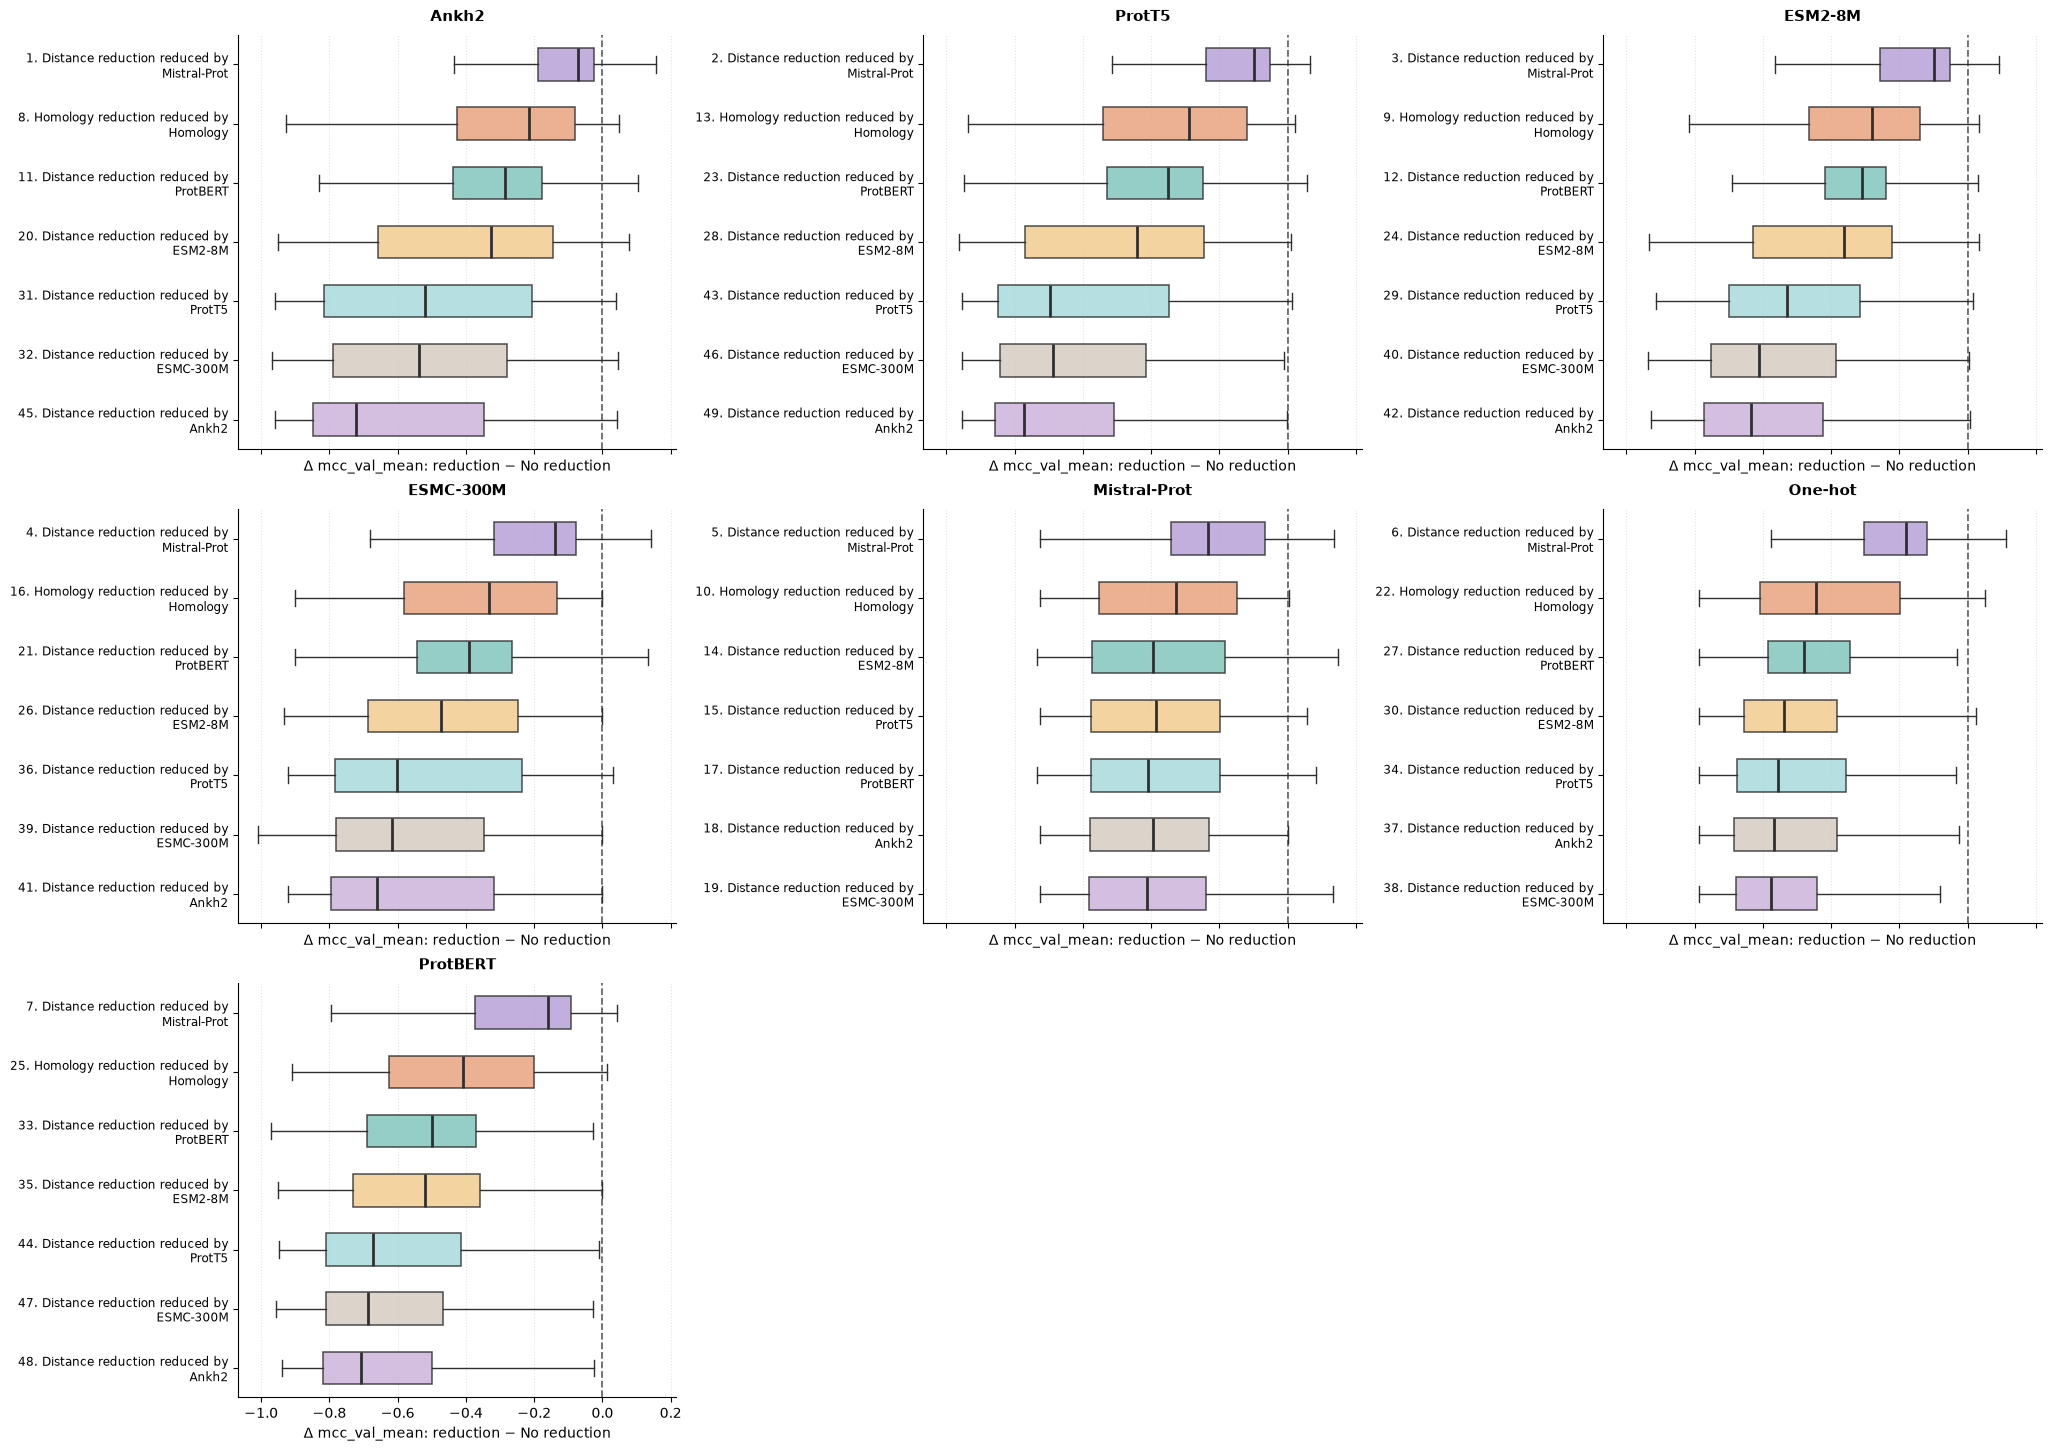

In [12]:
plot_R2_reduction_ranking_boxplot_pretty(
    delta_reduction_rank=delta_reduction_rank,
    R2_reduction_ranking=R2_reduction_ranking,
    partition_name="Random",
    metric=PRIMARY_METRIC,
    top_n_per_representation=8,
    ncols=3,
    output_file="R2_reduction_ranking_boxplot_random.png",
)

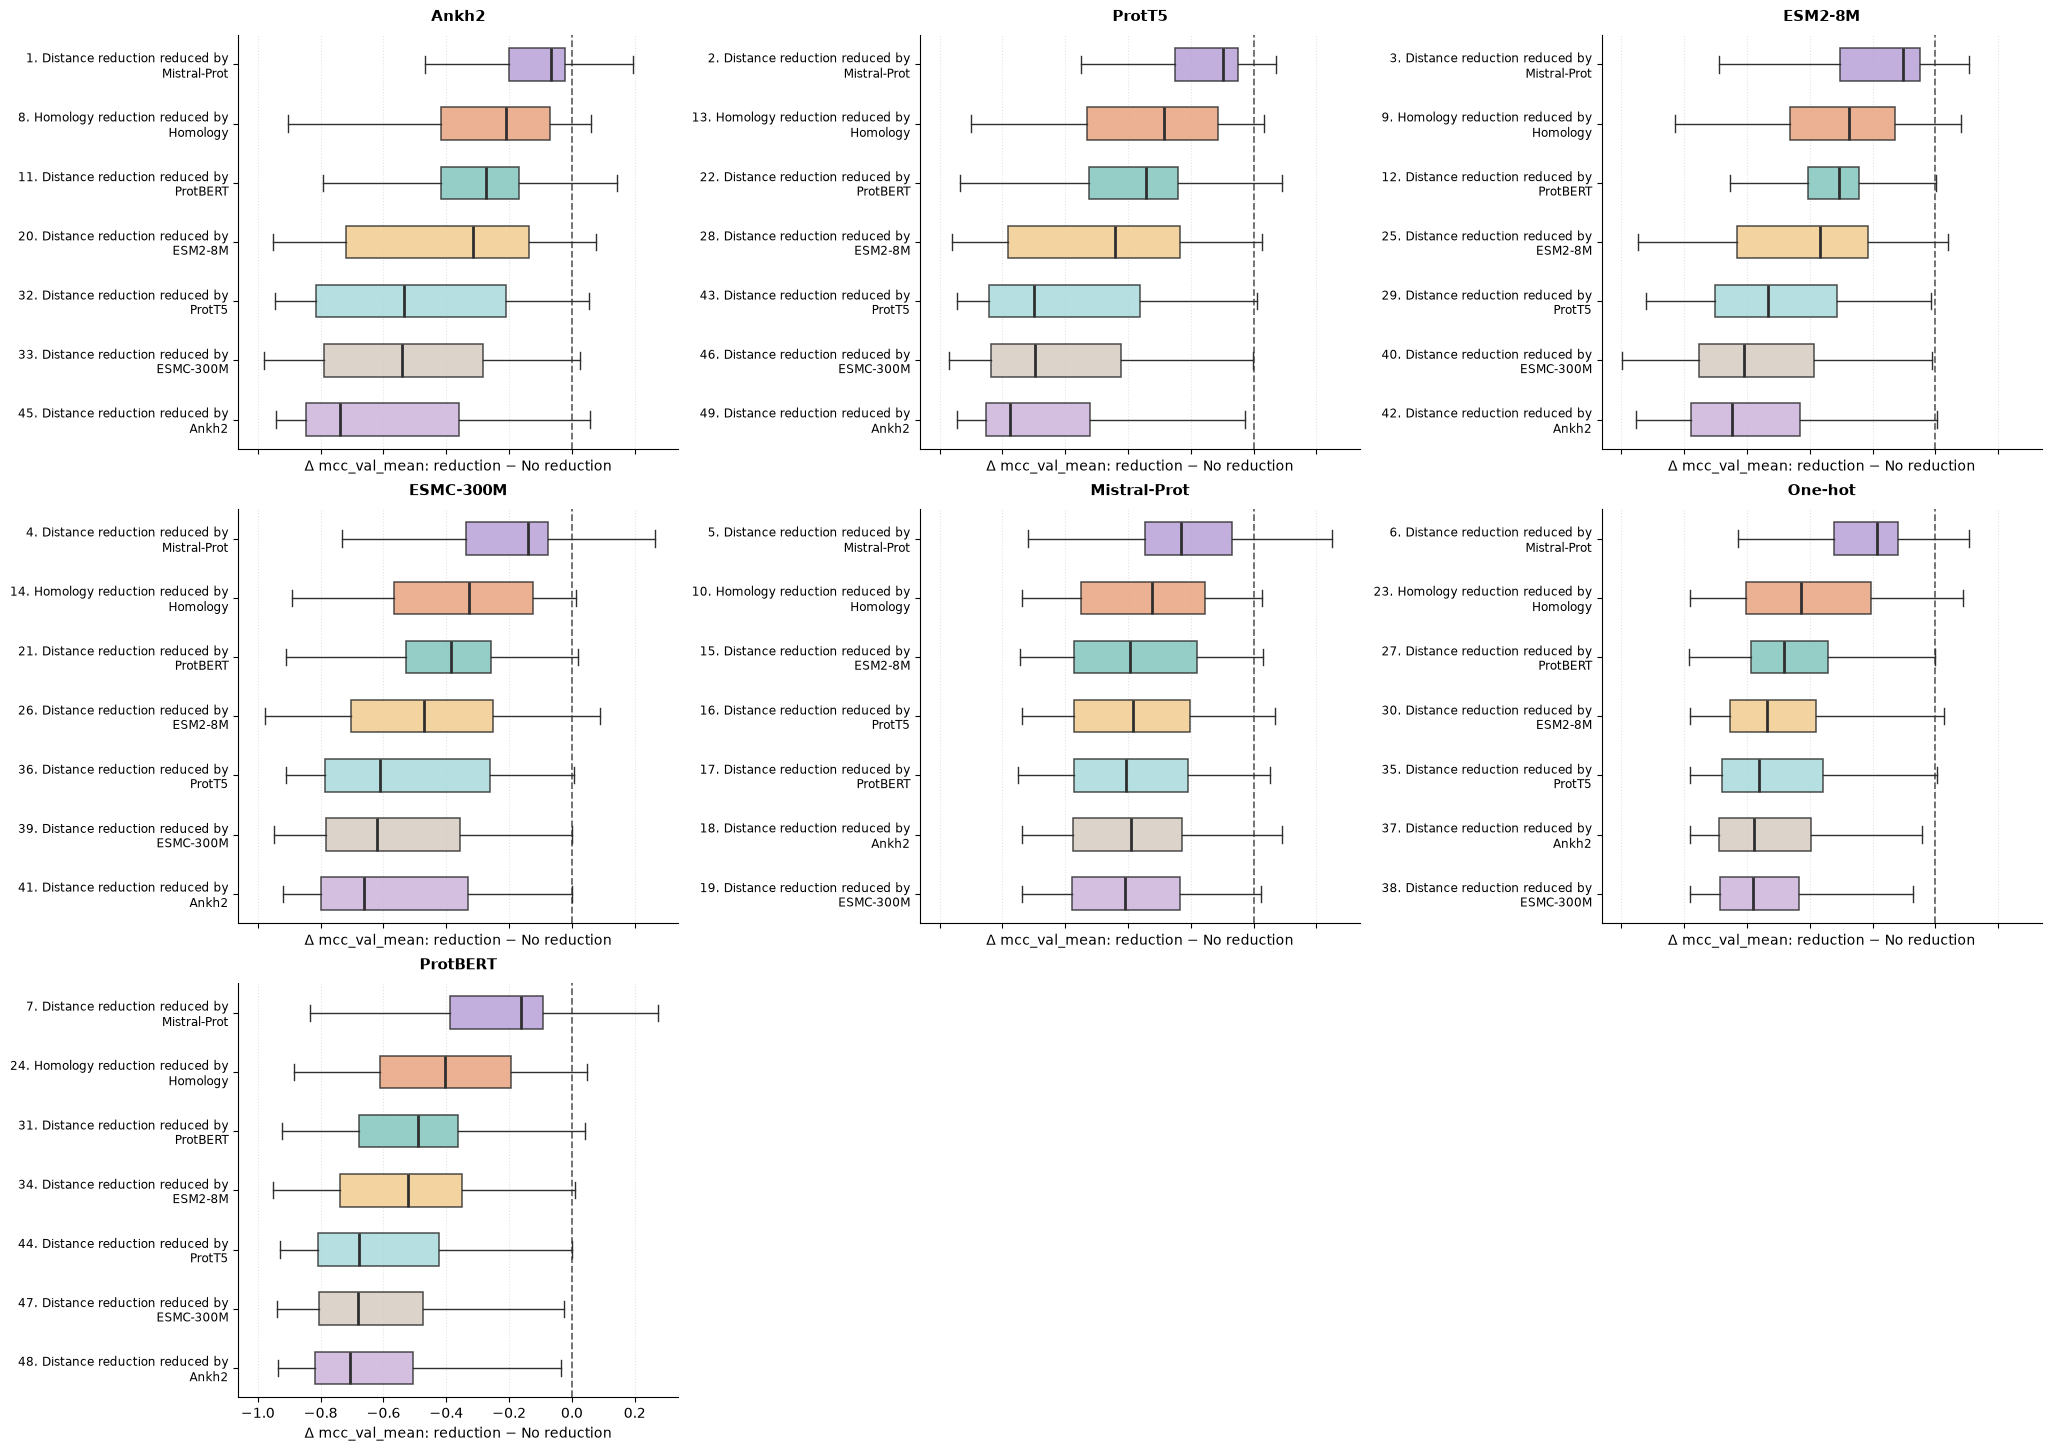

In [13]:
plot_R2_reduction_ranking_boxplot_pretty(
    delta_reduction_rank=delta_reduction_rank,
    R2_reduction_ranking=R2_reduction_ranking,
    partition_name="Stratified",
    metric=PRIMARY_METRIC,
    top_n_per_representation=8,
    ncols=3,
    output_file="R2_reduction_ranking_boxplot_stratified.png",
)

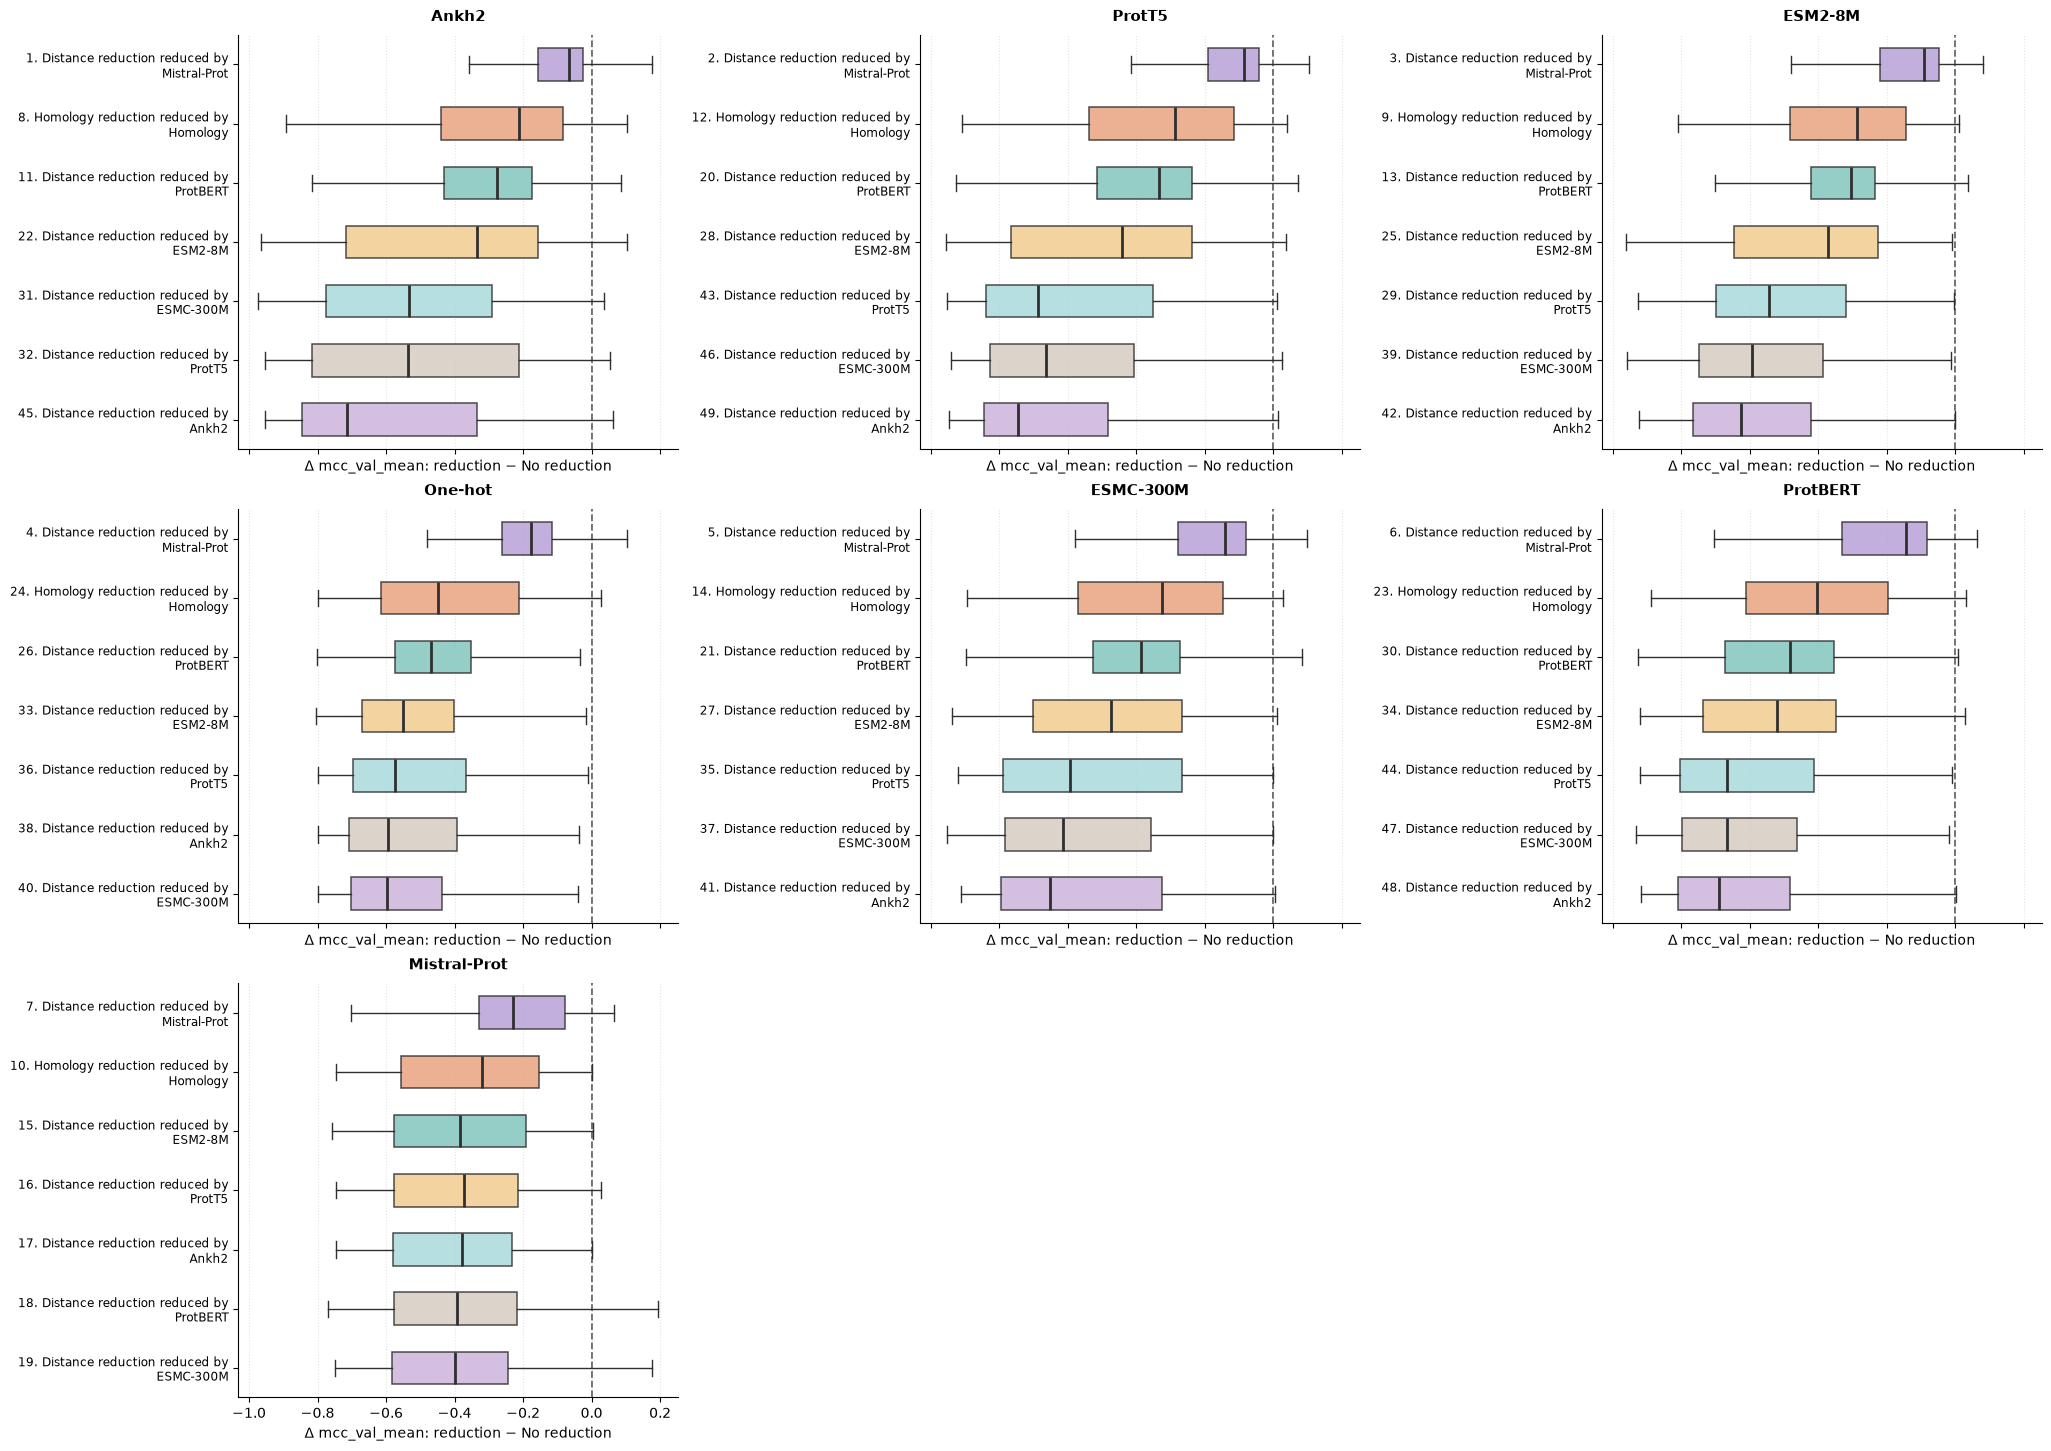

In [14]:
plot_R2_reduction_ranking_boxplot_pretty(
    delta_reduction_rank=delta_reduction_rank,
    R2_reduction_ranking=R2_reduction_ranking,
    partition_name="Distance-aware",
    metric=PRIMARY_METRIC,
    top_n_per_representation=8,
    ncols=3,
    output_file="R2_reduction_ranking_boxplot_distance.png",
)

- Question 3: Which embedding best improves or preserves performance compared to One-hot?

In [15]:
R3_group_cols = [
    "representation_label",
    "partition_label",
]

R3_representation_ranking = make_decision_ranking(
    delta_df=delta_rep_vs_onehot,
    group_cols=R3_group_cols,
    primary_metric=PRIMARY_METRIC,
    secondary_metric=SECONDARY_METRIC,
    rank_context_cols=[],  # ranking único global
    performance_filter="median",
    min_pairs=5,
)

print("R3_representation_ranking shape:", R3_representation_ranking.shape)
display(R3_representation_ranking.head())

R3_representation_ranking shape: (18, 32)


,representation_label,partition_label,n_pairs,n_seeds,baseline_mean__mcc_val_mean,candidate_mean__mcc_val_mean,delta_mean__mcc_val_mean,delta_median__mcc_val_mean,delta_std__mcc_val_mean,loss_mean__mcc_val_mean,...,retention_mean__f1_val_mean,prop_negative_delta__f1_val_mean,prop_delta_below_minus_005__f1_val_mean,prop_delta_below_minus_010__f1_val_mean,performance_threshold,passes_min_pairs,passes_performance_filter,rank_by_lowest_loss,decision_rank,decision_class
0,ProtT5,Random,960,30,0.582555,0.832249,0.249694,0.221680,0.115269,-0.249694,...,1.462703,0.000000,0.0,0.0,0.761139,True,True,1,1,Recommended
1,ProtT5,Stratified,960,30,0.583056,0.827001,0.243945,0.216541,0.117335,-0.243945,...,1.454380,0.000000,0.0,0.0,0.761139,True,True,2,2,Recommended
2,ESM2-8M,Random,960,30,0.582555,0.820456,0.237901,0.212728,0.128318,-0.237901,...,1.435092,0.000000,0.0,0.0,0.761139,True,True,3,3,Recommended
3,ESM2-8M,Stratified,960,30,0.583056,0.815380,0.232324,0.210135,0.127984,-0.232324,...,1.424784,0.002083,0.0,0.0,0.761139,True,True,4,4,Recommended
4,ProtT5,Distance-aware,960,30,0.603150,0.823625,0.220475,0.193260,0.118460,-0.220475,...,1.381006,0.011458,0.0,0.0,0.761139,True,True,5,5,Recommended


In [16]:
R3_cols_to_show = [
    c for c in R3_cols_to_show
    if c in R3_representation_ranking.columns
]

display(
    R3_representation_ranking[R3_cols_to_show]
    .sort_values(
        "rank_by_lowest_loss",
        na_position="last",
    )
)

,representation_label,partition_label,n_pairs,n_seeds,baseline_mean__mcc_val_mean,candidate_mean__mcc_val_mean,delta_mean__mcc_val_mean,delta_median__mcc_val_mean,delta_std__mcc_val_mean,loss_mean__mcc_val_mean,retention_mean__mcc_val_mean,prop_negative_delta__mcc_val_mean,prop_delta_below_minus_005__mcc_val_mean,prop_delta_below_minus_010__mcc_val_mean,rank_by_lowest_loss,decision_rank,decision_class
0,ProtT5,Random,960,30,0.582555,0.832249,0.249694,0.221680,0.115269,-0.249694,1.552894,0.000000,0.000000,0.000000,1,1,Recommended
1,ProtT5,Stratified,960,30,0.583056,0.827001,0.243945,0.216541,0.117335,-0.243945,1.543155,0.000000,0.000000,0.000000,2,2,Recommended
2,ESM2-8M,Random,960,30,0.582555,0.820456,0.237901,0.212728,0.128318,-0.237901,1.542726,0.000000,0.000000,0.000000,3,3,Recommended
3,ESM2-8M,Stratified,960,30,0.583056,0.815380,0.232324,0.210135,0.127984,-0.232324,1.530981,0.002083,0.000000,0.000000,4,4,Recommended
4,ProtT5,Distance-aware,960,30,0.603150,0.823625,0.220475,0.193260,0.118460,-0.220475,1.479438,0.008333,0.000000,0.000000,5,5,Recommended
5,ESM2-8M,Distance-aware,960,30,0.603150,0.813914,0.210764,0.190987,0.125959,-0.210764,1.468734,0.010417,0.000000,0.000000,6,6,Recommended
6,ProtBERT,Random,960,30,0.582555,0.768238,0.185683,0.185030,0.086051,-0.185683,1.395298,0.058333,0.004167,0.000000,7,7,Recommended
7,ProtBERT,Stratified,960,30,0.583056,0.765758,0.182702,0.182001,0.087657,-0.182702,1.390101,0.058333,0.014583,0.000000,8,8,Recommended
9,Ankh2,Random,960,30,0.582555,0.755506,0.172951,0.226241,0.316510,-0.172951,1.467189,0.093750,0.093750,0.093750,9,<NA>,Low performance or insufficient evidence
10,Ankh2,Stratified,960,30,0.583056,0.750275,0.167219,0.217980,0.315451,-0.167219,1.456123,0.093750,0.093750,0.093750,10,<NA>,Low performance or insufficient evidence


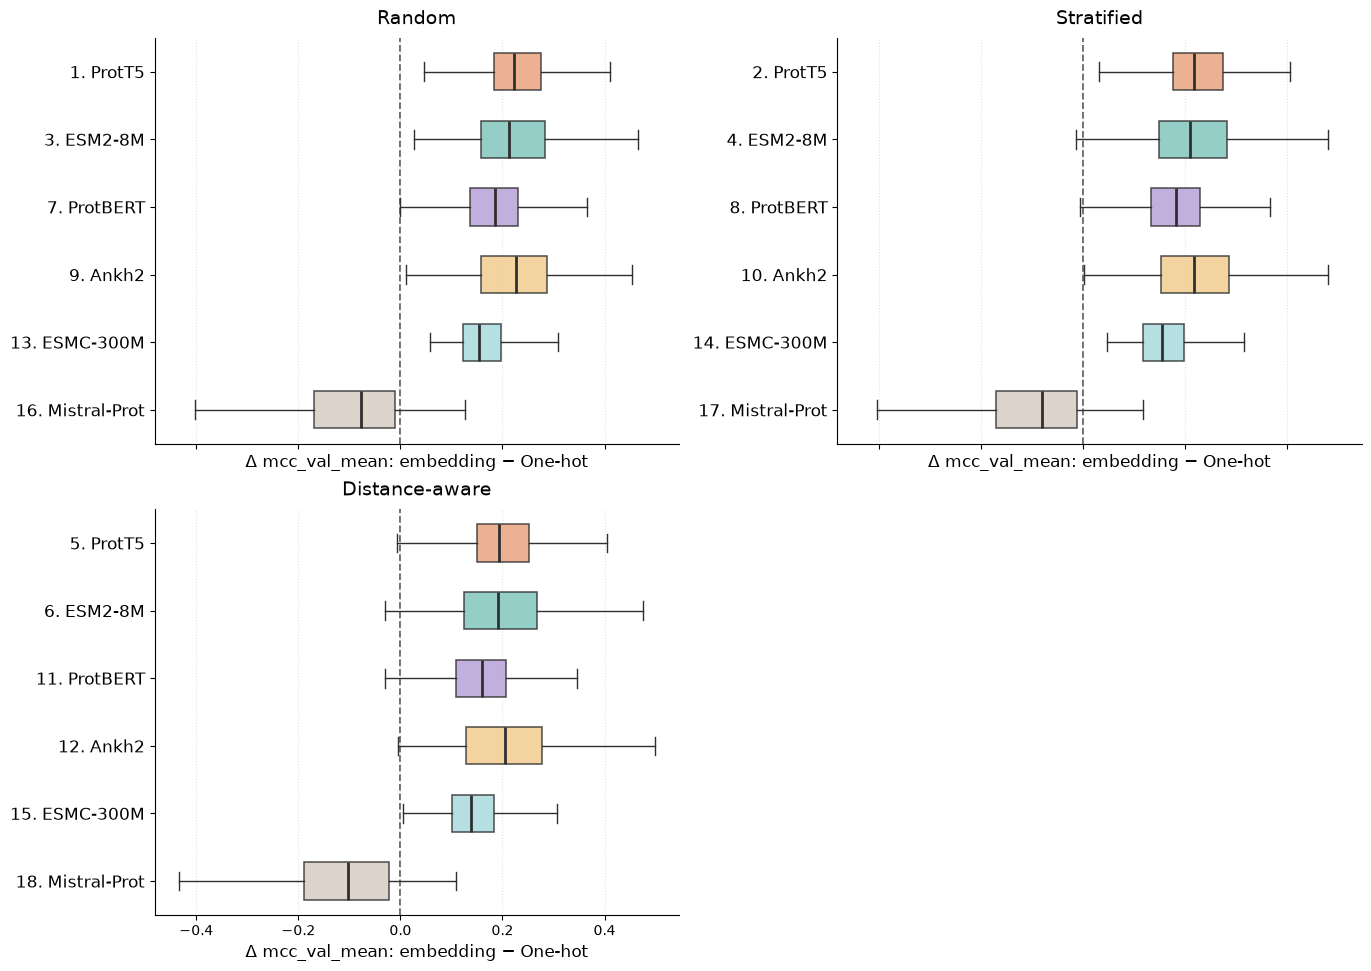

In [17]:
plot_R3_representation_ranking_boxplot_pretty(
    delta_rep_vs_onehot=delta_rep_vs_onehot,
    R3_representation_ranking=R3_representation_ranking,
    metric=PRIMARY_METRIC,
    top_n_per_partition=10,
    ncols=2,
    output_file="R3_representation_ranking_boxplot_pretty.png",
)

- Question 4: Does normalization improve or worsen performance compared to not normalizing?

In [18]:
CANDIDATE_SCALERS = [
    scaler for scaler in sorted(df["scaler"].dropna().astype(str).unique())
    if scaler != BASELINE_SCALER
]

baseline_filter_scaler = (
    df["scaler"].astype(str).eq(BASELINE_SCALER)
)

candidate_filter_scaler = (
    df["scaler"].astype(str).isin(CANDIDATE_SCALERS)
)

delta_scaler = compute_paired_delta(
    dataframe=df,
    baseline_filter=baseline_filter_scaler,
    candidate_filter=candidate_filter_scaler,
    match_cols=scaler_match_cols,
    candidate_context_cols=scaler_context_cols,
    metric_cols=METRICS,
    comparison_name="Scaler effect relative to none",
)

print("delta_scaler shape:", delta_scaler.shape)
display(delta_scaler.head())

delta_scaler shape: (868608, 66)


,representation_clean,algorithm,partition_label,cfg_idx,seed,reduction_strategy_clean,reduction_label,reduced_by,reduced_by_label,reduction_level,...,delta__recall_test_mean,loss__recall_test_mean,retention__recall_test_mean,delta__f1_test_mean,loss__f1_test_mean,retention__f1_test_mean,delta__mcc_test_mean,loss__mcc_test_mean,retention__mcc_test_mean,comparison_name
0,ankh2_ext1,DecisionTreeClassifier,Distance-aware,0,113,distance_reduction,Distance reduction,ankh2_ext1,Ankh2,p90_0,...,0.000000,0.000000,NaN,0.000000,0.000000,NaN,0.008732,-0.008732,0.804079,Scaler effect relative to none
1,ankh2_ext1,DecisionTreeClassifier,Distance-aware,0,113,distance_reduction,Distance reduction,ankh2_ext1,Ankh2,p95_0,...,0.041667,-0.041667,1.416667,0.074248,-0.074248,2.007092,0.078621,-0.078621,3.332378,Scaler effect relative to none
2,ankh2_ext1,DecisionTreeClassifier,Distance-aware,0,113,distance_reduction,Distance reduction,ankh2_ext1,Ankh2,p97_0,...,-0.007222,0.007222,0.896000,-0.022051,0.022051,0.601852,-0.028973,0.028973,-1.356523,Scaler effect relative to none
3,ankh2_ext1,DecisionTreeClassifier,Distance-aware,0,113,distance_reduction,Distance reduction,ankh2_ext1,Ankh2,p98_0,...,0.067949,-0.067949,2.432432,0.034406,-0.034406,1.633230,0.038156,-0.038156,4.398833,Scaler effect relative to none
4,ankh2_ext1,DecisionTreeClassifier,Distance-aware,0,113,distance_reduction,Distance reduction,ankh2_ext1,Ankh2,p99_0,...,-0.011558,0.011558,0.915295,-0.001699,0.001699,0.982832,-0.016196,0.016196,0.773473,Scaler effect relative to none


In [19]:
R4_group_cols = [
    "scaler",
]

R4_scaler_ranking = make_decision_ranking(
    delta_df=delta_scaler,
    group_cols=R4_group_cols,
    primary_metric=PRIMARY_METRIC,
    secondary_metric=SECONDARY_METRIC,
    rank_context_cols=[],  # ranking único global
    performance_filter="median",
    min_pairs=5,
)

print("R4_scaler_ranking shape:", R4_scaler_ranking.shape)
display(R4_scaler_ranking)

R4_scaler_ranking shape: (1, 31)


,scaler,n_pairs,n_seeds,baseline_mean__mcc_val_mean,candidate_mean__mcc_val_mean,delta_mean__mcc_val_mean,delta_median__mcc_val_mean,delta_std__mcc_val_mean,loss_mean__mcc_val_mean,loss_median__mcc_val_mean,...,retention_mean__f1_val_mean,prop_negative_delta__f1_val_mean,prop_delta_below_minus_005__f1_val_mean,prop_delta_below_minus_010__f1_val_mean,performance_threshold,passes_min_pairs,passes_performance_filter,rank_by_lowest_loss,decision_rank,decision_class
0,normalizer_l2,868608,30,0.310782,0.292523,-0.018259,0.0,0.143078,0.018259,0.0,...,0.941985,0.347952,0.13684,0.089302,0.292523,True,True,1,1,Recommended


In [20]:
R4_cols_to_show = [
    c for c in R4_cols_to_show
    if c in R4_scaler_ranking.columns
]

display(
    R4_scaler_ranking[R4_cols_to_show]
    .sort_values("rank_by_lowest_loss", na_position="last")
)

,scaler,n_pairs,n_seeds,baseline_mean__mcc_val_mean,candidate_mean__mcc_val_mean,delta_mean__mcc_val_mean,delta_median__mcc_val_mean,delta_std__mcc_val_mean,loss_mean__mcc_val_mean,retention_mean__mcc_val_mean,prop_negative_delta__mcc_val_mean,prop_delta_below_minus_005__mcc_val_mean,prop_delta_below_minus_010__mcc_val_mean,rank_by_lowest_loss,decision_rank,decision_class
0,normalizer_l2,868608,30,0.310782,0.292523,-0.018259,0.0,0.143078,0.018259,0.81681,0.355489,0.146085,0.093377,1,1,Recommended


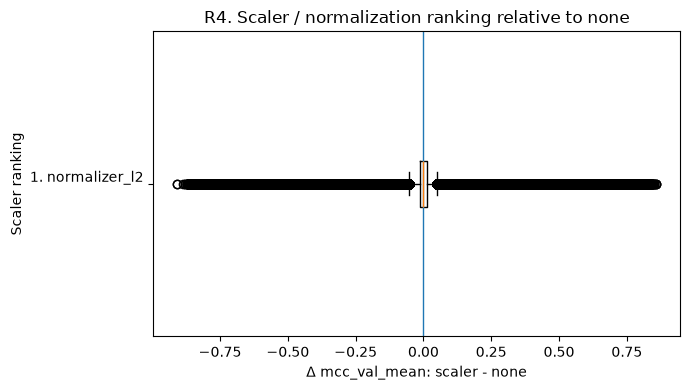

In [21]:
# %%
plot_R4_scaler_ranking_boxplot(
    delta_scaler=delta_scaler,
    R4_scaler_ranking=R4_scaler_ranking,
    metric=PRIMARY_METRIC,
    rank_col="rank_by_lowest_loss",
    output_file=f"{folder_path}/R4_scaler_ranking_boxplot.png",
)

- Question 5: Which algorithm is more robust against the methodological changes we have already evaluated?

In [22]:
# %%
algorithm_delta_sources = [
    ("partition", delta_partition),
    ("reduction", delta_reduction_rank),
    ("representation_vs_onehot", delta_rep_vs_onehot),
]

# Add scaler deltas only if they already exist
if "delta_scaler" in globals():
    algorithm_delta_sources.append(("scaler", delta_scaler))

delta_algorithm_pool_list = []

for source_name, source_df in algorithm_delta_sources:
    tmp = source_df.copy()
    tmp["ranking_source"] = source_name
    delta_algorithm_pool_list.append(tmp)

delta_algorithm_pool = pd.concat(
    delta_algorithm_pool_list,
    ignore_index=True,
    sort=False,
)

print("delta_algorithm_pool shape:", delta_algorithm_pool.shape)

display(
    delta_algorithm_pool
    .groupby(["ranking_source", "algorithm"], dropna=False)
    .size()
    .reset_index(name="n_pairs")
    .sort_values(["ranking_source", "algorithm"])
)

delta_algorithm_pool shape: (2800992, 70)


,ranking_source,algorithm,n_pairs
0,partition,DecisionTreeClassifier,4050
1,partition,GaussianNB,2430
2,partition,KNeighborsClassifier,4050
3,partition,LogisticRegression,3240
4,partition,RandomForestClassifier,4860
5,partition,SVC,4050
6,partition,XGBClassifier,3240
7,reduction,DecisionTreeClassifier,295185
8,reduction,GaussianNB,177111
9,reduction,KNeighborsClassifier,295185


In [23]:
R5_group_cols = [
    "algorithm",
]

R5_algorithm_ranking = make_decision_ranking(
    delta_df=delta_algorithm_pool,
    group_cols=R5_group_cols,
    primary_metric=PRIMARY_METRIC,
    secondary_metric=SECONDARY_METRIC,
    rank_context_cols=[],  # global algorithm ranking
    performance_filter="median",
    min_pairs=5,
)

print("R5_algorithm_ranking shape:", R5_algorithm_ranking.shape)
display(R5_algorithm_ranking)

R5_algorithm_ranking shape: (7, 31)


,algorithm,n_pairs,n_seeds,baseline_mean__mcc_val_mean,candidate_mean__mcc_val_mean,delta_mean__mcc_val_mean,delta_median__mcc_val_mean,delta_std__mcc_val_mean,loss_mean__mcc_val_mean,loss_median__mcc_val_mean,...,retention_mean__f1_val_mean,prop_negative_delta__f1_val_mean,prop_delta_below_minus_005__f1_val_mean,prop_delta_below_minus_010__f1_val_mean,performance_threshold,passes_min_pairs,passes_performance_filter,rank_by_lowest_loss,decision_rank,decision_class
0,GaussianNB,262593,30,0.493497,0.308927,-0.184570,-0.148530,0.210489,0.184570,0.148530,...,0.664143,0.814283,0.662261,0.599704,0.298304,True,True,1,1,Recommended
1,KNeighborsClassifier,437655,30,0.634015,0.362184,-0.271831,-0.177871,0.293642,0.271831,0.177871,...,0.581802,0.753006,0.657493,0.589202,0.298304,True,True,2,2,Recommended
2,XGBClassifier,350124,30,0.706374,0.395751,-0.310624,-0.215167,0.319765,0.310624,0.215167,...,0.566725,0.786327,0.667872,0.596857,0.298304,True,True,5,3,Recommended
3,RandomForestClassifier,525186,30,0.634978,0.298304,-0.336674,-0.272865,0.328840,0.336674,0.272865,...,0.477554,0.755275,0.673460,0.626797,0.298304,True,True,7,4,Recommended
4,DecisionTreeClassifier,437655,30,0.520581,0.241358,-0.279223,-0.261473,0.263772,0.279223,0.261473,...,0.596288,0.818293,0.720823,0.661469,0.298304,True,False,3,<NA>,Low performance or insufficient evidence
5,SVC,437655,30,0.527994,0.247892,-0.280102,-0.145328,0.328777,0.280102,0.145328,...,0.433870,0.664153,0.591338,0.543535,0.298304,True,False,4,<NA>,Low performance or insufficient evidence
6,LogisticRegression,350124,30,0.502705,0.173426,-0.329279,-0.322096,0.323388,0.329279,0.322096,...,0.278419,0.728465,0.698718,0.662434,0.298304,True,False,6,<NA>,Low performance or insufficient evidence


In [24]:
R5_cols_to_show = [
    c for c in R5_cols_to_show
    if c in R5_algorithm_ranking.columns
]

display(
    R5_algorithm_ranking[R5_cols_to_show]
    .sort_values("rank_by_lowest_loss", na_position="last")
)

,algorithm,n_pairs,n_seeds,baseline_mean__mcc_val_mean,candidate_mean__mcc_val_mean,delta_mean__mcc_val_mean,delta_median__mcc_val_mean,delta_std__mcc_val_mean,loss_mean__mcc_val_mean,retention_mean__mcc_val_mean,prop_negative_delta__mcc_val_mean,prop_delta_below_minus_005__mcc_val_mean,prop_delta_below_minus_010__mcc_val_mean,rank_by_lowest_loss,decision_rank,decision_class
0,GaussianNB,262593,30,0.493497,0.308927,-0.184570,-0.148530,0.210489,0.184570,0.653545,0.803894,0.650432,0.564025,1,1,Recommended
1,KNeighborsClassifier,437655,30,0.634015,0.362184,-0.271831,-0.177871,0.293642,0.271831,0.578673,0.749961,0.646013,0.574000,2,2,Recommended
4,DecisionTreeClassifier,437655,30,0.520581,0.241358,-0.279223,-0.261473,0.263772,0.279223,0.452107,0.822257,0.724827,0.661702,3,<NA>,Low performance or insufficient evidence
5,SVC,437655,30,0.527994,0.247892,-0.280102,-0.145328,0.328777,0.280102,0.442884,0.661373,0.583542,0.533018,4,<NA>,Low performance or insufficient evidence
2,XGBClassifier,350124,30,0.706374,0.395751,-0.310624,-0.215167,0.319765,0.310624,0.573775,0.790717,0.664345,0.588983,5,3,Recommended
6,LogisticRegression,350124,30,0.502705,0.173426,-0.329279,-0.322096,0.323388,0.329279,0.293393,0.725897,0.693060,0.650644,6,<NA>,Low performance or insufficient evidence
3,RandomForestClassifier,525186,30,0.634978,0.298304,-0.336674,-0.272865,0.328840,0.336674,0.493878,0.759803,0.669437,0.611145,7,4,Recommended


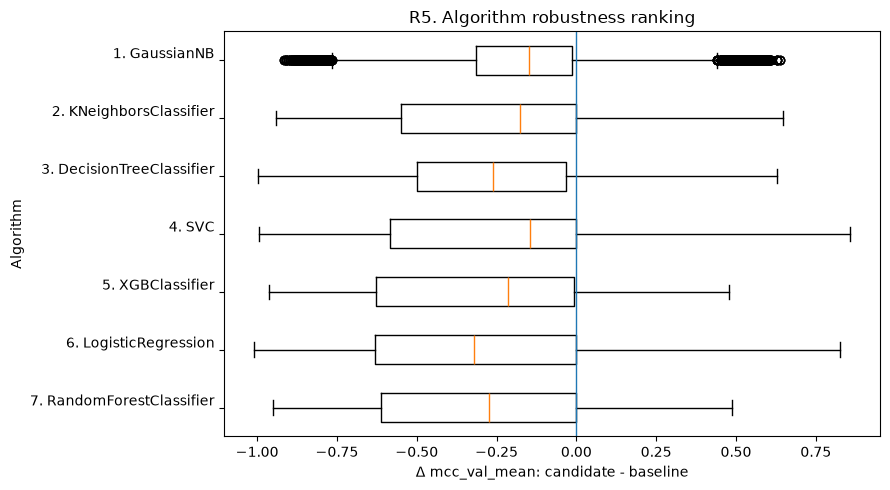

In [25]:
plot_R5_algorithm_ranking_boxplot(
    delta_algorithm_pool=delta_algorithm_pool,
    R5_algorithm_ranking=R5_algorithm_ranking,
    metric=PRIMARY_METRIC,
    rank_col="rank_by_lowest_loss",
    output_file=f"{folder_path}/R5_algorithm_ranking_boxplot.png",
)

- A1. Algorithm vs. Partition (Which algorithm loses less when switching from Random to another partition?)

In [26]:
S1_group_cols = [
    "baseline_context",
    "partition_label",
    "algorithm",
]

S1_algorithm_partition_ranking = make_decision_ranking(
    delta_df=delta_partition,
    group_cols=S1_group_cols,
    primary_metric=PRIMARY_METRIC,
    secondary_metric=SECONDARY_METRIC,
    rank_context_cols=[
        "baseline_context",
        "partition_label",
    ],
    performance_filter="median",
    min_pairs=5,
)

print("S1_algorithm_partition_ranking shape:", S1_algorithm_partition_ranking.shape)
display(S1_algorithm_partition_ranking.head())

S1_algorithm_partition_ranking shape: (35, 33)


,baseline_context,partition_label,algorithm,n_pairs,n_seeds,baseline_mean__mcc_val_mean,candidate_mean__mcc_val_mean,delta_mean__mcc_val_mean,delta_median__mcc_val_mean,delta_std__mcc_val_mean,...,retention_mean__f1_val_mean,prop_negative_delta__f1_val_mean,prop_delta_below_minus_005__f1_val_mean,prop_delta_below_minus_010__f1_val_mean,performance_threshold,passes_min_pairs,passes_performance_filter,rank_by_lowest_loss,decision_rank,decision_class
0,B1: One-hot + No reduction,Distance-aware,SVC,150,30,0.618180,0.647584,0.029404,0.025447,0.021928,...,1.080864,0.066667,0.0,0.0,0.619468,True,True,1,1,Recommended
1,B1: One-hot + No reduction,Distance-aware,XGBClassifier,120,30,0.707512,0.732133,0.024621,0.022764,0.021429,...,1.034951,0.150000,0.0,0.0,0.619468,True,True,2,2,Recommended
2,B1: One-hot + No reduction,Distance-aware,LogisticRegression,120,30,0.727946,0.750814,0.022868,0.025766,0.021696,...,1.027589,0.141667,0.0,0.0,0.619468,True,True,3,3,Recommended
3,B1: One-hot + No reduction,Distance-aware,KNeighborsClassifier,150,30,0.597514,0.619468,0.021954,0.020098,0.029646,...,1.044478,0.120000,0.0,0.0,0.619468,True,True,4,4,Recommended
4,B1: One-hot + No reduction,Distance-aware,RandomForestClassifier,180,30,0.586866,0.605873,0.019008,0.018374,0.023063,...,1.042267,0.227778,0.0,0.0,0.619468,True,False,5,<NA>,Low performance or insufficient evidence


In [27]:
S1_cols_to_show = [
    "baseline_context",
    "partition_label",
    "algorithm",
    "n_pairs",
    "n_seeds",
    f"baseline_mean__{PRIMARY_METRIC}",
    f"candidate_mean__{PRIMARY_METRIC}",
    f"delta_mean__{PRIMARY_METRIC}",
    f"delta_median__{PRIMARY_METRIC}",
    f"delta_std__{PRIMARY_METRIC}",
    f"loss_mean__{PRIMARY_METRIC}",
    f"retention_mean__{PRIMARY_METRIC}",
    f"prop_negative_delta__{PRIMARY_METRIC}",
    f"prop_delta_below_minus_005__{PRIMARY_METRIC}",
    f"prop_delta_below_minus_010__{PRIMARY_METRIC}",
    "rank_by_lowest_loss",
    "decision_rank",
    "decision_class",
]

S1_cols_to_show = [
    c for c in S1_cols_to_show
    if c in S1_algorithm_partition_ranking.columns
]

display(
    S1_algorithm_partition_ranking[S1_cols_to_show]
    .sort_values(
        [
            "baseline_context",
            "partition_label",
            "rank_by_lowest_loss",
        ],
        na_position="last",
    )
)

,baseline_context,partition_label,algorithm,n_pairs,n_seeds,baseline_mean__mcc_val_mean,candidate_mean__mcc_val_mean,delta_mean__mcc_val_mean,delta_median__mcc_val_mean,delta_std__mcc_val_mean,loss_mean__mcc_val_mean,retention_mean__mcc_val_mean,prop_negative_delta__mcc_val_mean,prop_delta_below_minus_005__mcc_val_mean,prop_delta_below_minus_010__mcc_val_mean,rank_by_lowest_loss,decision_rank,decision_class
0,B1: One-hot + No reduction,Distance-aware,SVC,150,30,0.618180,0.647584,0.029404,0.025447,0.021928,-0.029404,1.058842,0.073333,0.000000,0.000000,1,1,Recommended
1,B1: One-hot + No reduction,Distance-aware,XGBClassifier,120,30,0.707512,0.732133,0.024621,0.022764,0.021429,-0.024621,1.035351,0.150000,0.000000,0.000000,2,2,Recommended
2,B1: One-hot + No reduction,Distance-aware,LogisticRegression,120,30,0.727946,0.750814,0.022868,0.025766,0.021696,-0.022868,1.031841,0.125000,0.000000,0.000000,3,3,Recommended
3,B1: One-hot + No reduction,Distance-aware,KNeighborsClassifier,150,30,0.597514,0.619468,0.021954,0.020098,0.029646,-0.021954,1.038438,0.153333,0.013333,0.000000,4,4,Recommended
4,B1: One-hot + No reduction,Distance-aware,RandomForestClassifier,180,30,0.586866,0.605873,0.019008,0.018374,0.023063,-0.019008,1.033028,0.227778,0.000000,0.000000,5,<NA>,Low performance or insufficient evidence
5,B1: One-hot + No reduction,Distance-aware,DecisionTreeClassifier,150,30,0.508597,0.524224,0.015628,0.014135,0.030632,-0.015628,1.032304,0.306667,0.020000,0.000000,6,<NA>,Low performance or insufficient evidence
6,B1: One-hot + No reduction,Distance-aware,GaussianNB,90,30,0.252428,0.259129,0.006701,0.005734,0.028066,-0.006701,1.033723,0.366667,0.033333,0.000000,7,<NA>,Low performance or insufficient evidence
7,B1: One-hot + No reduction,Distance-aware normalized,SVC,150,30,0.618180,0.647584,0.029404,0.025447,0.021928,-0.029404,1.058842,0.073333,0.000000,0.000000,1,1,Recommended
8,B1: One-hot + No reduction,Distance-aware normalized,XGBClassifier,120,30,0.707512,0.732133,0.024621,0.022764,0.021429,-0.024621,1.035351,0.150000,0.000000,0.000000,2,2,Recommended
9,B1: One-hot + No reduction,Distance-aware normalized,LogisticRegression,120,30,0.727946,0.750814,0.022868,0.025766,0.021696,-0.022868,1.031841,0.125000,0.000000,0.000000,3,3,Recommended


- A2: Which algorithm loses less when reduction is applied compared to No reduction?

In [28]:
# %%
S2_group_cols = [
    "partition_label",
    "reduction_label",
    "algorithm",
]

S2_algorithm_reduction_ranking = make_decision_ranking(
    delta_df=delta_reduction_rank,
    group_cols=S2_group_cols,
    primary_metric=PRIMARY_METRIC,
    secondary_metric=SECONDARY_METRIC,
    rank_context_cols=[
        "partition_label",
        "reduction_label",
    ],
    performance_filter="median",
    min_pairs=5,
)

print("S2_algorithm_reduction_ranking shape:", S2_algorithm_reduction_ranking.shape)
display(S2_algorithm_reduction_ranking.head())

S2_algorithm_reduction_ranking shape: (56, 33)


,partition_label,reduction_label,algorithm,n_pairs,n_seeds,baseline_mean__mcc_val_mean,candidate_mean__mcc_val_mean,delta_mean__mcc_val_mean,delta_median__mcc_val_mean,delta_std__mcc_val_mean,...,retention_mean__f1_val_mean,prop_negative_delta__f1_val_mean,prop_delta_below_minus_005__f1_val_mean,prop_delta_below_minus_010__f1_val_mean,performance_threshold,passes_min_pairs,passes_performance_filter,rank_by_lowest_loss,decision_rank,decision_class
0,Distance-aware,Distance reduction,GaussianNB,52275,30,0.579269,0.297528,-0.281741,-0.261773,0.184483,...,0.498396,0.983778,0.935648,0.875638,0.282543,True,True,1,1,Recommended
1,Distance-aware,Distance reduction,KNeighborsClassifier,87125,30,0.760730,0.345222,-0.415508,-0.415525,0.263437,...,0.413871,0.991529,0.948304,0.865033,0.282543,True,True,3,2,Recommended
2,Distance-aware,Distance reduction,XGBClassifier,69700,30,0.845199,0.379271,-0.465928,-0.456151,0.286784,...,0.404356,0.999139,0.959627,0.874319,0.282543,True,True,6,3,Recommended
3,Distance-aware,Distance reduction,RandomForestClassifier,104550,30,0.789081,0.282543,-0.506538,-0.555236,0.274893,...,0.303538,0.999598,0.982343,0.925194,0.282543,True,True,7,4,Recommended
4,Distance-aware,Distance reduction,SVC,87125,30,0.641324,0.241248,-0.400075,-0.353686,0.312709,...,0.305522,0.883478,0.802743,0.740224,0.282543,True,False,2,<NA>,Low performance or insufficient evidence


In [29]:
# %%
S2_cols_to_show = [
    "partition_label",
    "reduction_label",
    "algorithm",
    "n_pairs",
    "n_seeds",
    f"baseline_mean__{PRIMARY_METRIC}",
    f"candidate_mean__{PRIMARY_METRIC}",
    f"delta_mean__{PRIMARY_METRIC}",
    f"delta_median__{PRIMARY_METRIC}",
    f"delta_std__{PRIMARY_METRIC}",
    f"loss_mean__{PRIMARY_METRIC}",
    f"retention_mean__{PRIMARY_METRIC}",
    f"prop_negative_delta__{PRIMARY_METRIC}",
    f"prop_delta_below_minus_005__{PRIMARY_METRIC}",
    f"prop_delta_below_minus_010__{PRIMARY_METRIC}",
    "rank_by_lowest_loss",
    "decision_rank",
    "decision_class",
]

S2_cols_to_show = [
    c for c in S2_cols_to_show
    if c in S2_algorithm_reduction_ranking.columns
]

3. Algorithm versus normalization

In [30]:
# %%
S3_group_cols = [
    "scaler",
    "algorithm",
]

S3_algorithm_scaler_ranking = make_decision_ranking(
    delta_df=delta_scaler,
    group_cols=S3_group_cols,
    primary_metric=PRIMARY_METRIC,
    secondary_metric=SECONDARY_METRIC,
    rank_context_cols=[
        "scaler",
    ],
    performance_filter="median",
    min_pairs=5,
)

print("S3_algorithm_scaler_ranking shape:", S3_algorithm_scaler_ranking.shape)
display(S3_algorithm_scaler_ranking.head())

S3_algorithm_scaler_ranking shape: (7, 32)


,scaler,algorithm,n_pairs,n_seeds,baseline_mean__mcc_val_mean,candidate_mean__mcc_val_mean,delta_mean__mcc_val_mean,delta_median__mcc_val_mean,delta_std__mcc_val_mean,loss_mean__mcc_val_mean,...,retention_mean__f1_val_mean,prop_negative_delta__f1_val_mean,prop_delta_below_minus_005__f1_val_mean,prop_delta_below_minus_010__f1_val_mean,performance_threshold,passes_min_pairs,passes_performance_filter,rank_by_lowest_loss,decision_rank,decision_class
0,normalizer_l2,KNeighborsClassifier,135720,30,0.369640,0.381716,0.012077,0.000881,0.050104,-0.012077,...,1.027219,0.255136,0.050516,0.016372,0.312761,True,True,1,1,Recommended
1,normalizer_l2,GaussianNB,81432,30,0.320576,0.327951,0.007375,0.000000,0.062765,-0.007375,...,1.015289,0.466844,0.087926,0.022411,0.312761,True,True,2,2,Recommended
2,normalizer_l2,RandomForestClassifier,162864,30,0.308391,0.312761,0.004370,0.000000,0.036480,-0.004370,...,1.037943,0.243387,0.029810,0.006570,0.312761,True,True,4,3,Recommended
3,normalizer_l2,XGBClassifier,108576,30,0.409361,0.409551,0.000190,0.000000,0.042008,-0.000190,...,0.995652,0.343575,0.057932,0.015224,0.312761,True,True,5,4,Recommended
4,normalizer_l2,DecisionTreeClassifier,135720,30,0.245312,0.251935,0.006623,0.005314,0.074977,-0.006623,...,1.066070,0.445542,0.156617,0.046574,0.312761,True,False,3,<NA>,Low performance or insufficient evidence


In [31]:
# %%
S3_cols_to_show = [
    "scaler",
    "algorithm",
    "n_pairs",
    "n_seeds",
    f"baseline_mean__{PRIMARY_METRIC}",
    f"candidate_mean__{PRIMARY_METRIC}",
    f"delta_mean__{PRIMARY_METRIC}",
    f"delta_median__{PRIMARY_METRIC}",
    f"delta_std__{PRIMARY_METRIC}",
    f"loss_mean__{PRIMARY_METRIC}",
    f"retention_mean__{PRIMARY_METRIC}",
    f"prop_negative_delta__{PRIMARY_METRIC}",
    f"prop_delta_below_minus_005__{PRIMARY_METRIC}",
    f"prop_delta_below_minus_010__{PRIMARY_METRIC}",
    "rank_by_lowest_loss",
    "decision_rank",
    "decision_class",
]

S3_cols_to_show = [
    c for c in S3_cols_to_show
    if c in S3_algorithm_scaler_ranking.columns
]

display(
    S3_algorithm_scaler_ranking[S3_cols_to_show]
    .sort_values(
        [
            "scaler",
            "rank_by_lowest_loss",
        ],
        na_position="last",
    )
)

,scaler,algorithm,n_pairs,n_seeds,baseline_mean__mcc_val_mean,candidate_mean__mcc_val_mean,delta_mean__mcc_val_mean,delta_median__mcc_val_mean,delta_std__mcc_val_mean,loss_mean__mcc_val_mean,retention_mean__mcc_val_mean,prop_negative_delta__mcc_val_mean,prop_delta_below_minus_005__mcc_val_mean,prop_delta_below_minus_010__mcc_val_mean,rank_by_lowest_loss,decision_rank,decision_class
0,normalizer_l2,KNeighborsClassifier,135720,30,0.369640,0.381716,0.012077,0.000881,0.050104,-0.012077,0.918787,0.262717,0.055725,0.020631,1,1,Recommended
1,normalizer_l2,GaussianNB,81432,30,0.320576,0.327951,0.007375,0.000000,0.062765,-0.007375,1.004724,0.466622,0.122802,0.029288,2,2,Recommended
4,normalizer_l2,DecisionTreeClassifier,135720,30,0.245312,0.251935,0.006623,0.005314,0.074977,-0.006623,0.685975,0.459240,0.176643,0.061752,3,<NA>,Low performance or insufficient evidence
2,normalizer_l2,RandomForestClassifier,162864,30,0.308391,0.312761,0.004370,0.000000,0.036480,-0.004370,0.960239,0.259321,0.039026,0.010856,4,3,Recommended
3,normalizer_l2,XGBClassifier,108576,30,0.409361,0.409551,0.000190,0.000000,0.042008,-0.000190,0.917278,0.359481,0.065033,0.022381,5,4,Recommended
5,normalizer_l2,SVC,135720,30,0.281683,0.238093,-0.043590,0.000000,0.202224,0.043590,0.754486,0.292109,0.178537,0.152594,6,<NA>,Low performance or insufficient evidence
6,normalizer_l2,LogisticRegression,108576,30,0.253081,0.125846,-0.127236,0.000000,0.282080,0.127236,0.308330,0.477905,0.439379,0.392665,7,<NA>,Low performance or insufficient evidence


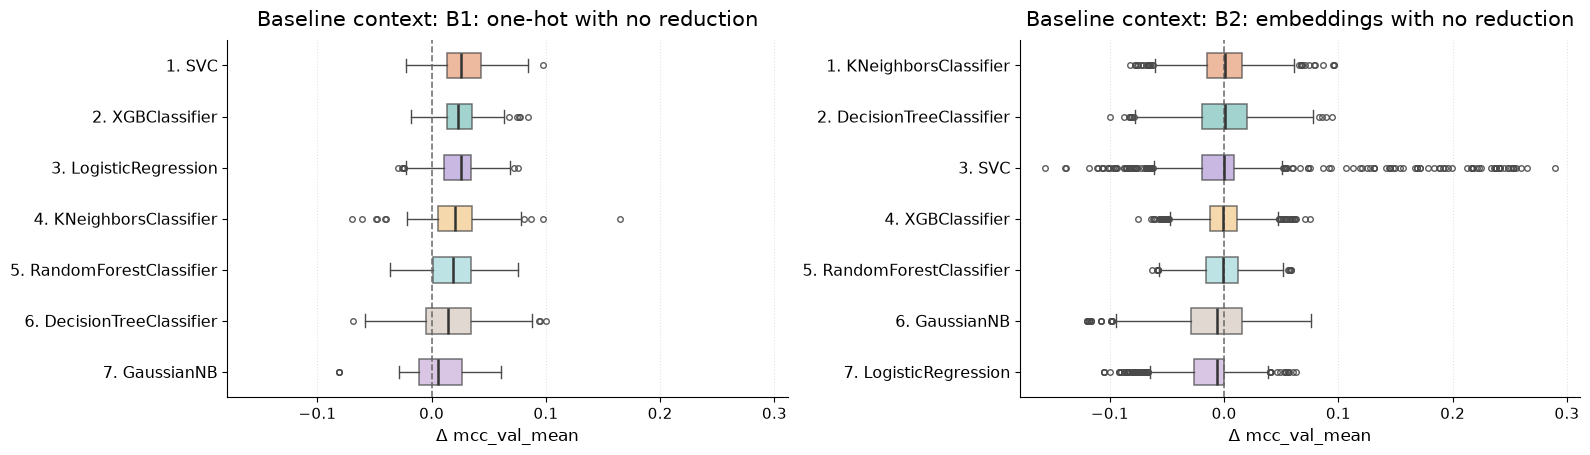

In [32]:
plot_algorithm_sensitivity_boxplot_pretty_original_style(
    delta_df=delta_partition,
    ranking_df=S1_algorithm_partition_ranking,
    group_cols=[
        "baseline_context",
        "partition_label",
        "algorithm",
    ],
    panel_col="baseline_context",
    metric=PRIMARY_METRIC,
    rank_col="rank_by_lowest_loss",
    filters={
        "partition_label": "Distance-aware",
    },
    top_n_per_panel=10,
    ncols=2,
    #title="S1. Algorithm sensitivity to Distance-aware partition",
    output_file=f"{folder_path}/S1_algorithm_sensitivity_distanceaware_partition.png",
)

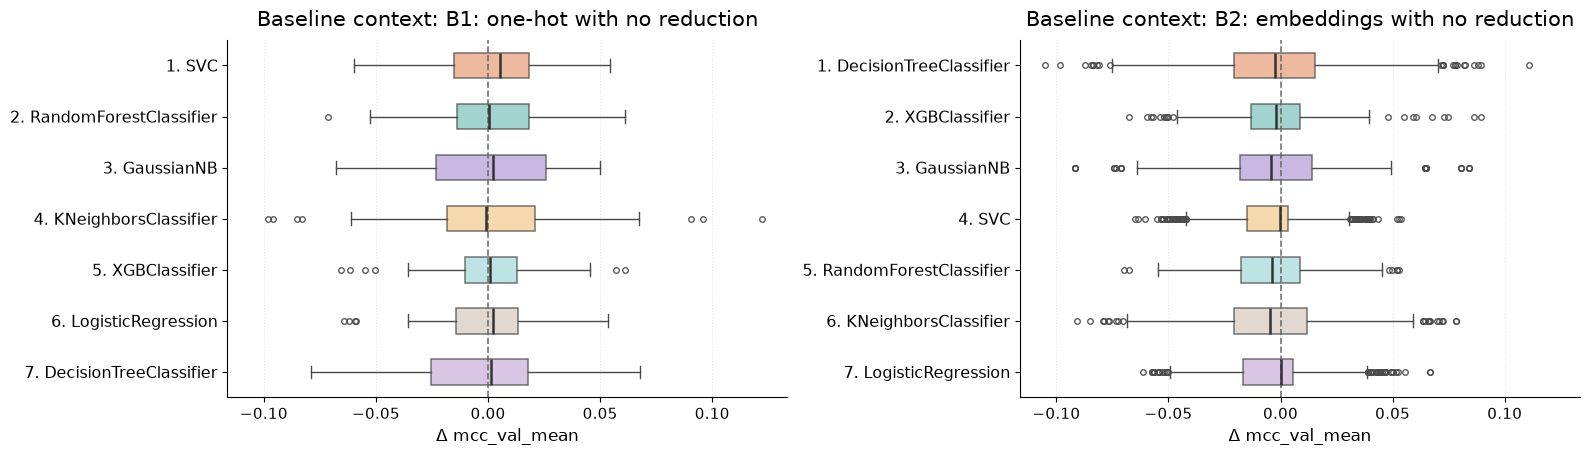

In [33]:
plot_algorithm_sensitivity_boxplot_pretty_original_style(
    delta_df=delta_partition,
    ranking_df=S1_algorithm_partition_ranking,
    group_cols=[
        "baseline_context",
        "partition_label",
        "algorithm",
    ],
    panel_col="baseline_context",
    metric=PRIMARY_METRIC,
    rank_col="rank_by_lowest_loss",
    filters={
        "partition_label": "Stratified",
    },
    top_n_per_panel=10,
    ncols=2,
    #title="S1. Algorithm sensitivity to Distance-aware partition",
    output_file=f"{folder_path}/S1_algorithm_sensitivity_stratified_partition.png",
)

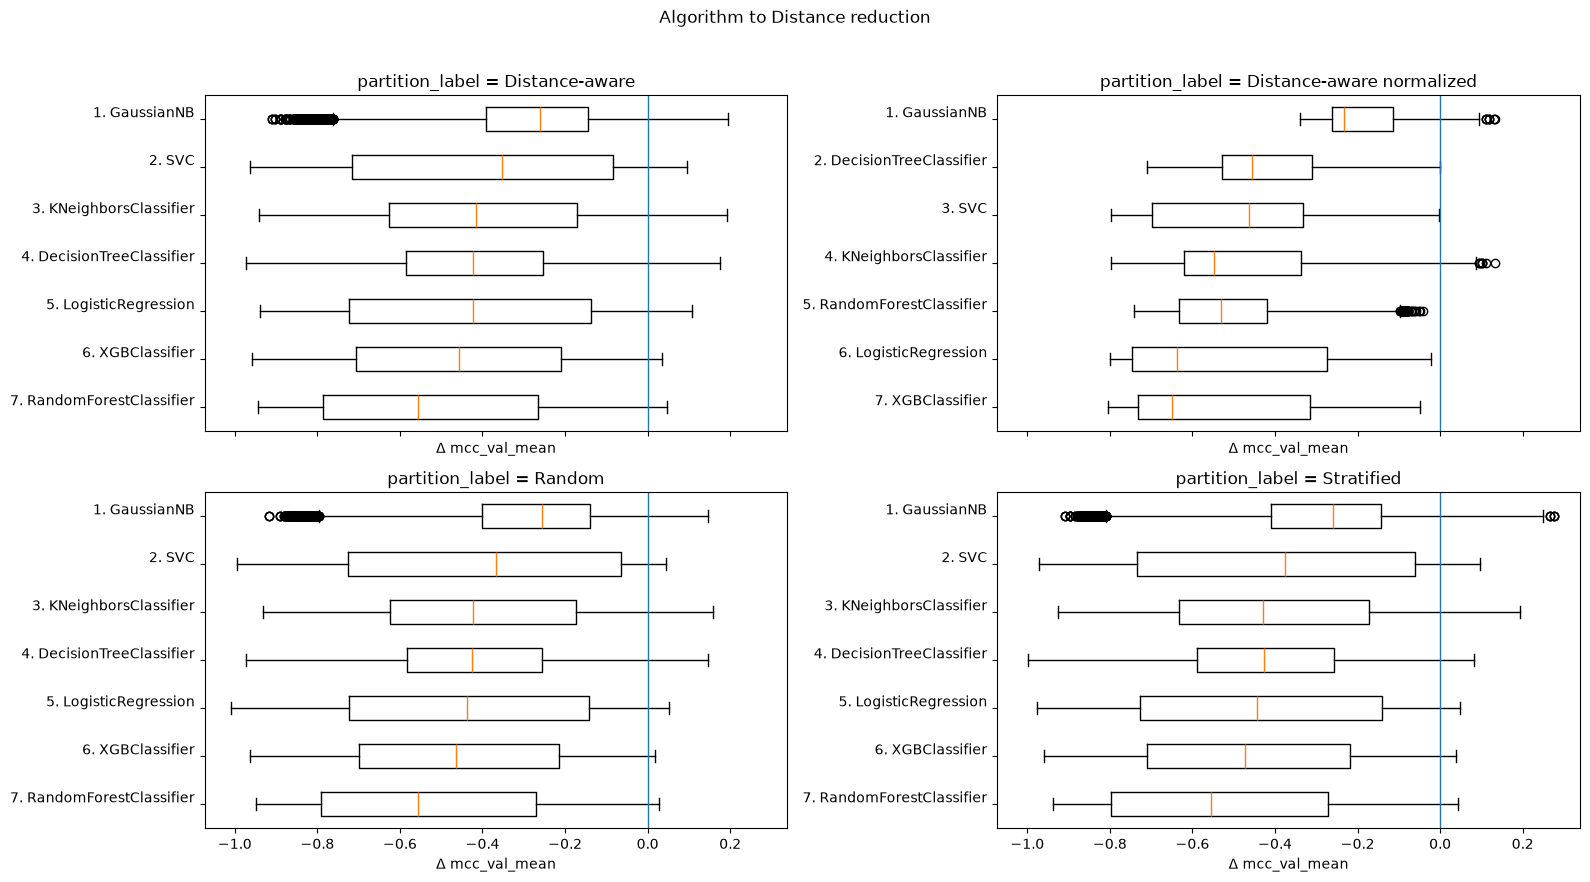

In [34]:
# %%
plot_algorithm_sensitivity_boxplot(
    delta_df=delta_reduction_rank,
    ranking_df=S2_algorithm_reduction_ranking,
    group_cols=[
        "partition_label",
        "reduction_label",
        "algorithm",
    ],
    panel_col="partition_label",
    metric=PRIMARY_METRIC,
    rank_col="rank_by_lowest_loss",
    filters={
        "reduction_label": "Distance reduction",
    },
    top_n_per_panel=10,
    ncols=2,
    title="Algorithm to Distance reduction",
    output_file=f"{folder_path}/S2_algorithm_sensitivity_distance_reduction.png",
)

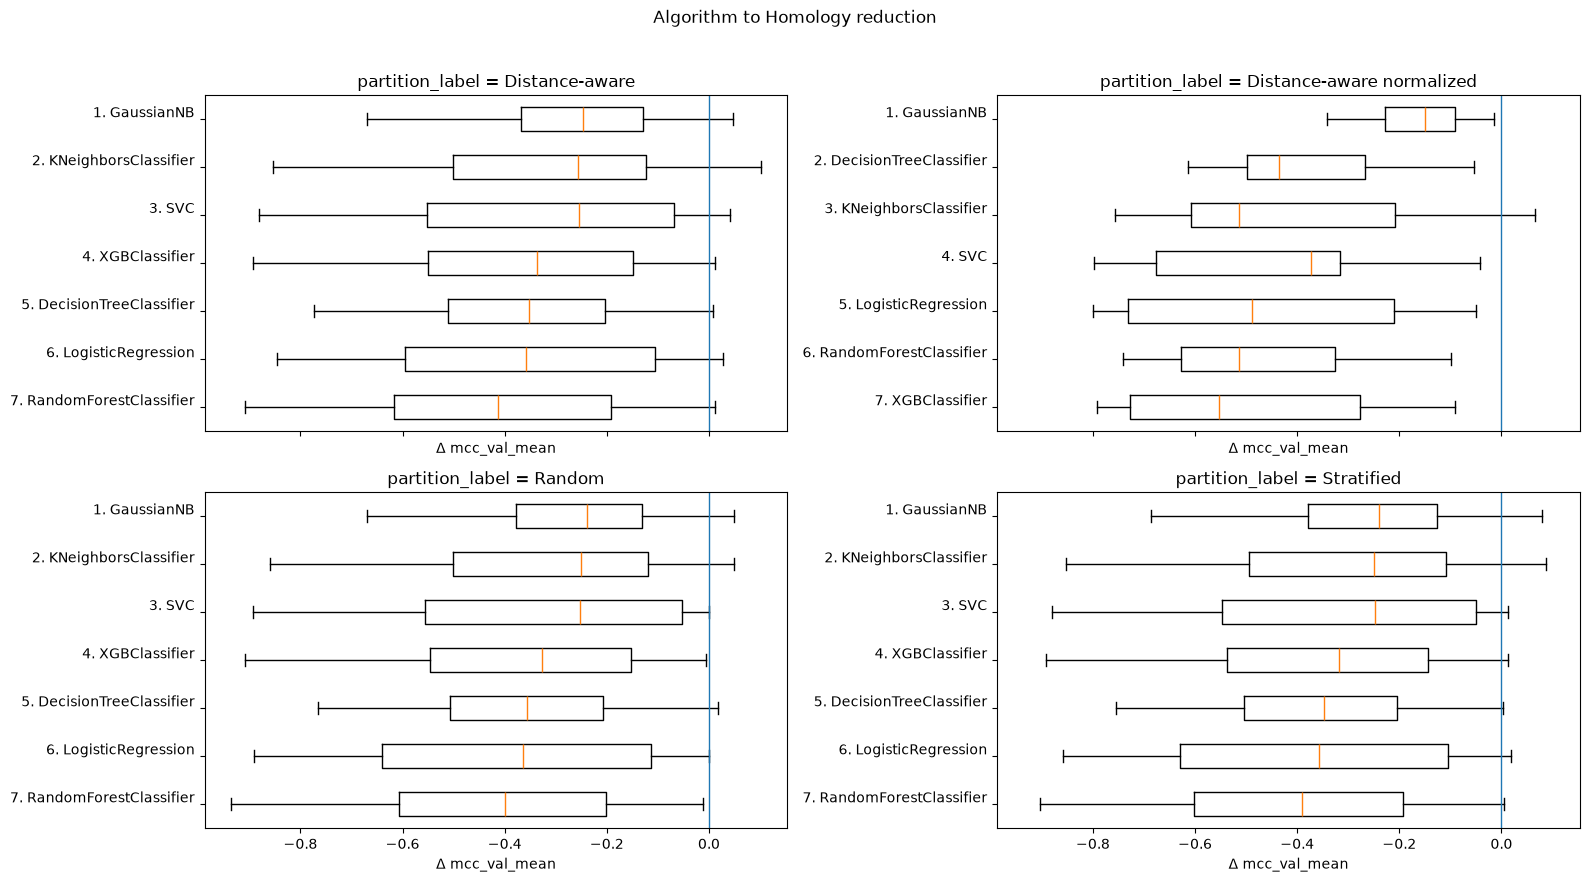

In [35]:
# %%
plot_algorithm_sensitivity_boxplot(
    delta_df=delta_reduction_rank,
    ranking_df=S2_algorithm_reduction_ranking,
    group_cols=[
        "partition_label",
        "reduction_label",
        "algorithm",
    ],
    panel_col="partition_label",
    metric=PRIMARY_METRIC,
    rank_col="rank_by_lowest_loss",
    filters={
        "reduction_label": "Homology reduction",
    },
    top_n_per_panel=10,
    ncols=2,
    title="Algorithm to Homology reduction",
    output_file=f"{folder_path}/S2_algorithm_sensitivity_homology_reduction.png",
)

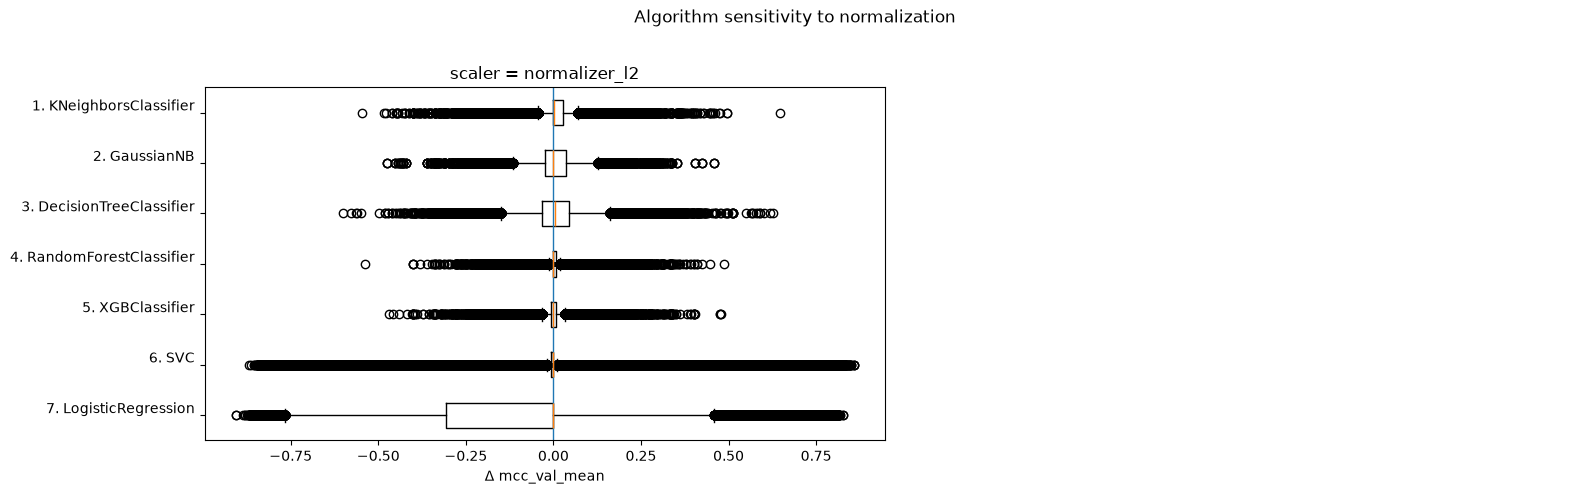

In [36]:
# %%
plot_algorithm_sensitivity_boxplot(
    delta_df=delta_scaler,
    ranking_df=S3_algorithm_scaler_ranking,
    group_cols=[
        "scaler",
        "algorithm",
    ],
    panel_col="scaler",
    metric=PRIMARY_METRIC,
    rank_col="rank_by_lowest_loss",
    filters=None,
    top_n_per_panel=10,
    ncols=2,
    title="Algorithm sensitivity to normalization",
    output_file=f"{folder_path}/S3_algorithm_sensitivity_scaler.png",
)

- Ranking of all combinations (Considering a complete combination, which one results in the least performance reduction?)

Baseline:
same representation + Random + No reduction + scaler=none

Candidate:
same representation + any partition + any reduction + any scaler

In [37]:
# %%
df_combo = df.copy()

df_combo["reduced_by_label_clean"] = (
    df_combo["reduced_by_label"]
    .astype("string")
    .fillna("not_applicable")
    .astype(str)
)

df_combo.loc[
    df_combo["reduction_label"].astype(str).eq("Homology reduction"),
    "reduced_by_label_clean"
] = "homology"

df_combo.loc[
    df_combo["reduction_label"].astype(str).eq("No reduction"),
    "reduced_by_label_clean"
] = "no_reduction"

df_combo["reduction_level_label_clean"] = (
    df_combo["reduction_level_label"]
    .astype("string")
    .fillna("not_applicable")
    .astype(str)
)

df_combo.loc[
    df_combo["reduction_label"].astype(str).eq("No reduction"),
    "reduction_level_label_clean"
] = "no_reduction"

In [38]:
# %%
COMBO_PARTITIONS = [
    "Random",
    "Stratified",
    "Distance-aware",
    "Distance-aware normalized",
]

COMBO_REDUCTIONS = [
    "No reduction",
    "Distance reduction",
    "Homology reduction",
]

BASELINE_COMBO_PARTITION = "Random"
BASELINE_COMBO_REDUCTION = "No reduction"
BASELINE_COMBO_SCALER = "none"

combo_match_cols = [
    "representation_clean",
    "algorithm",
    "cfg_idx",
    "seed",
]

combo_context_cols = [
    "representation_clean",
    "representation_label",
    "partition_label",
    "reduction_label",
    "reduced_by_label_clean",
    "reduction_level_label_clean",
    "scaler",
    "algorithm",
    "cfg_idx",
]

baseline_filter_combo = (
    df_combo["partition_label"].astype(str).eq(BASELINE_COMBO_PARTITION)
    &
    df_combo["reduction_label"].astype(str).eq(BASELINE_COMBO_REDUCTION)
    &
    df_combo["scaler"].astype(str).eq(BASELINE_COMBO_SCALER)
)

candidate_filter_combo = (
    df_combo["partition_label"].astype(str).isin(COMBO_PARTITIONS)
    &
    df_combo["reduction_label"].astype(str).isin(COMBO_REDUCTIONS)
)

# Excluir el baseline exacto como candidato para que no gane trivialmente con Δ=0
candidate_filter_combo = (
    candidate_filter_combo
    &
    ~baseline_filter_combo
)

delta_combination = compute_paired_delta(
    dataframe=df_combo,
    baseline_filter=baseline_filter_combo,
    candidate_filter=candidate_filter_combo,
    match_cols=combo_match_cols,
    candidate_context_cols=combo_context_cols,
    metric_cols=METRICS,
    comparison_name="Complete combination effect relative to same representation baseline",
)

print("delta_combination shape:", delta_combination.shape)
display(delta_combination.head())

delta_combination shape: (1920864, 61)


,representation_clean,algorithm,cfg_idx,seed,representation_label,partition_label,reduction_label,reduced_by_label_clean,reduction_level_label_clean,scaler,...,delta__recall_test_mean,loss__recall_test_mean,retention__recall_test_mean,delta__f1_test_mean,loss__f1_test_mean,retention__f1_test_mean,delta__mcc_test_mean,loss__mcc_test_mean,retention__mcc_test_mean,comparison_name
0,ankh2_ext1,DecisionTreeClassifier,0,113,Ankh2,Distance-aware,Distance reduction,Ankh2,p90_0,none,...,-0.855370,0.855370,0.000000,-0.820683,0.820683,0.000000,-0.806634,0.806634,-0.058487,Complete combination effect relative to same r...
1,ankh2_ext1,DecisionTreeClassifier,0,113,Ankh2,Distance-aware,Distance reduction,Ankh2,p90_0,normalizer_l2,...,-0.855370,0.855370,0.000000,-0.820683,0.820683,0.000000,-0.797901,0.797901,-0.047028,Complete combination effect relative to same r...
2,ankh2_ext1,DecisionTreeClassifier,0,113,Ankh2,Distance-aware,Distance reduction,Ankh2,p95_0,none,...,-0.755370,0.755370,0.116909,-0.746958,0.746958,0.089834,-0.728354,0.728354,0.044233,Complete combination effect relative to same r...
3,ankh2_ext1,DecisionTreeClassifier,0,113,Ankh2,Distance-aware,Distance reduction,Ankh2,p95_0,normalizer_l2,...,-0.713703,0.713703,0.165620,-0.672709,0.672709,0.180306,-0.649733,0.649733,0.147402,Complete combination effect relative to same r...
4,ankh2_ext1,DecisionTreeClassifier,0,113,Ankh2,Distance-aware,Distance reduction,Ankh2,p97_0,none,...,-0.785925,0.785925,0.081186,-0.765299,0.765299,0.067486,-0.749768,0.749768,0.016134,Complete combination effect relative to same r...


In [39]:
# %%
R5_group_cols = [
    "representation_label",
    "partition_label",
    "reduction_label",
    "reduced_by_label_clean",
    "scaler",
]

R5_combination_ranking = make_decision_ranking(
    delta_df=delta_combination,
    group_cols=R5_group_cols,
    primary_metric=PRIMARY_METRIC,
    secondary_metric=SECONDARY_METRIC,
    rank_context_cols=[],  # ranking único global
    performance_filter="median",
    min_pairs=5,
)

print("R5_combination_ranking shape:", R5_combination_ranking.shape)
display(R5_combination_ranking.head())

R5_combination_ranking shape: (313, 35)


,representation_label,partition_label,reduction_label,reduced_by_label_clean,scaler,n_pairs,n_seeds,baseline_mean__mcc_val_mean,candidate_mean__mcc_val_mean,delta_mean__mcc_val_mean,...,retention_mean__f1_val_mean,prop_negative_delta__f1_val_mean,prop_delta_below_minus_005__f1_val_mean,prop_delta_below_minus_010__f1_val_mean,performance_threshold,passes_min_pairs,passes_performance_filter,rank_by_lowest_loss,decision_rank,decision_class
0,Ankh2,Random,No reduction,no_reduction,normalizer_l2,960,30,0.755506,0.852066,0.096560,...,1.022574,0.293750,0.000000,0.0,0.262317,True,True,1,1,Recommended
1,Ankh2,Distance-aware,No reduction,no_reduction,normalizer_l2,960,30,0.755506,0.848896,0.093390,...,1.019639,0.330208,0.005208,0.0,0.262317,True,True,2,2,Recommended
2,Ankh2,Stratified,No reduction,no_reduction,normalizer_l2,960,30,0.755506,0.846625,0.091118,...,1.017371,0.364583,0.001042,0.0,0.262317,True,True,3,3,Recommended
3,One-hot,Distance-aware normalized,No reduction,no_reduction,none,960,30,0.582555,0.603233,0.020678,...,1.040142,0.180208,0.001042,0.0,0.262317,True,True,4,4,Recommended
4,One-hot,Distance-aware,No reduction,no_reduction,none,960,30,0.582555,0.603150,0.020595,...,1.040027,0.189583,0.001042,0.0,0.262317,True,True,5,5,Recommended


In [40]:
# %%
R5_cols_to_show = [
    "representation_label",
    "partition_label",
    "reduction_label",
    "reduced_by_label_clean",
    "scaler",
    "n_pairs",
    "n_seeds",
    f"baseline_mean__{PRIMARY_METRIC}",
    f"candidate_mean__{PRIMARY_METRIC}",
    f"delta_mean__{PRIMARY_METRIC}",
    f"delta_median__{PRIMARY_METRIC}",
    f"delta_std__{PRIMARY_METRIC}",
    f"loss_mean__{PRIMARY_METRIC}",
    f"retention_mean__{PRIMARY_METRIC}",
    f"prop_negative_delta__{PRIMARY_METRIC}",
    f"prop_delta_below_minus_005__{PRIMARY_METRIC}",
    f"prop_delta_below_minus_010__{PRIMARY_METRIC}",
    "rank_by_lowest_loss",
    "decision_rank",
    "decision_class",
]

R5_cols_to_show = [
    c for c in R5_cols_to_show
    if c in R5_combination_ranking.columns
]

display(
    R5_combination_ranking[R5_cols_to_show]
    .sort_values(
        "rank_by_lowest_loss",
        na_position="last",
    )
    .head(5)
)

,representation_label,partition_label,reduction_label,reduced_by_label_clean,scaler,n_pairs,n_seeds,baseline_mean__mcc_val_mean,candidate_mean__mcc_val_mean,delta_mean__mcc_val_mean,delta_median__mcc_val_mean,delta_std__mcc_val_mean,loss_mean__mcc_val_mean,retention_mean__mcc_val_mean,prop_negative_delta__mcc_val_mean,prop_delta_below_minus_005__mcc_val_mean,prop_delta_below_minus_010__mcc_val_mean,rank_by_lowest_loss,decision_rank,decision_class
0,Ankh2,Random,No reduction,no_reduction,normalizer_l2,960,30,0.755506,0.852066,0.096560,0.005429,0.231981,-0.096560,1.030441,0.287500,0.001042,0.0,1,1,Recommended
1,Ankh2,Distance-aware,No reduction,no_reduction,normalizer_l2,960,30,0.755506,0.848896,0.093390,0.012398,0.230439,-0.093390,1.027646,0.325000,0.011458,0.0,2,2,Recommended
2,Ankh2,Stratified,No reduction,no_reduction,normalizer_l2,960,30,0.755506,0.846625,0.091118,0.010647,0.231870,-0.091118,1.024118,0.367708,0.001042,0.0,3,3,Recommended
3,One-hot,Distance-aware normalized,No reduction,no_reduction,none,960,30,0.582555,0.603233,0.020678,0.019414,0.026263,-0.020678,1.038174,0.189583,0.008333,0.0,4,4,Recommended
4,One-hot,Distance-aware,No reduction,no_reduction,none,960,30,0.582555,0.603150,0.020595,0.019907,0.026122,-0.020595,1.038001,0.194792,0.008333,0.0,5,5,Recommended


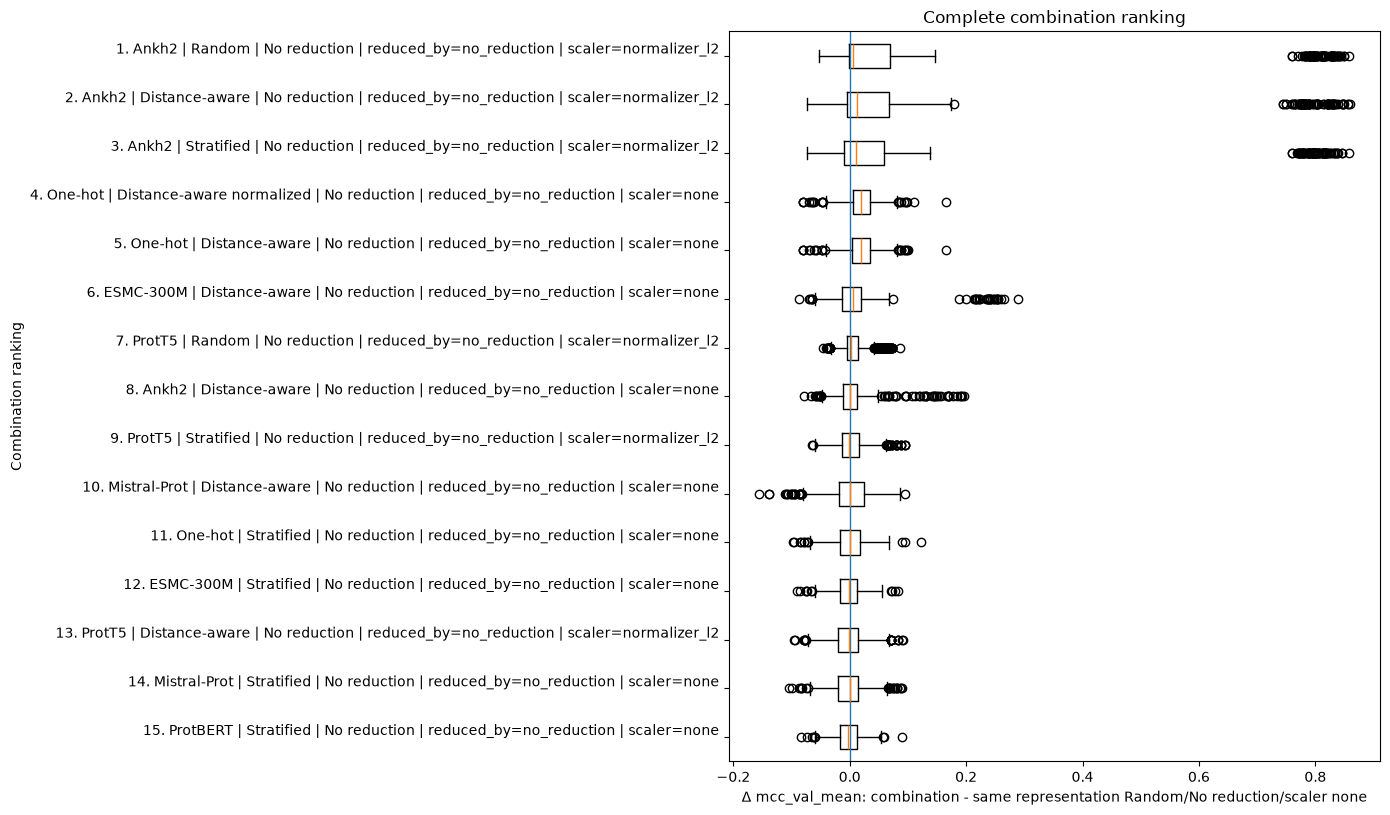

In [41]:
# %%
plot_R5_combination_ranking_boxplot(
    delta_combination=delta_combination,
    R5_combination_ranking=R5_combination_ranking,
    metric=PRIMARY_METRIC,
    top_n=15,
    rank_col="rank_by_lowest_loss",
    output_file=f"{folder_path}/R5_complete_combination_ranking_boxplot.png",
)

- Non-scaled training analysis

In [42]:
# %%
RE_group_cols = [
    "representation_label",
    "partition_label",
    "reduction_label",
    "reduced_by_label_clean",
]

RE_combination_ranking = make_decision_ranking(
    delta_df=delta_combination,
    group_cols=RE_group_cols,
    primary_metric=PRIMARY_METRIC,
    secondary_metric=SECONDARY_METRIC,
    rank_context_cols=[],  # ranking único global
    performance_filter="median",
    min_pairs=5,
)

print("RE_combination_ranking shape:", RE_combination_ranking.shape)
display(RE_combination_ranking.head())

RE_combination_ranking shape: (175, 34)


,representation_label,partition_label,reduction_label,reduced_by_label_clean,n_pairs,n_seeds,baseline_mean__mcc_val_mean,candidate_mean__mcc_val_mean,delta_mean__mcc_val_mean,delta_median__mcc_val_mean,...,retention_mean__f1_val_mean,prop_negative_delta__f1_val_mean,prop_delta_below_minus_005__f1_val_mean,prop_delta_below_minus_010__f1_val_mean,performance_threshold,passes_min_pairs,passes_performance_filter,rank_by_lowest_loss,decision_rank,decision_class
0,Ankh2,Random,No reduction,no_reduction,960,30,0.755506,0.852066,0.096560,0.005429,...,1.022574,0.293750,0.000000,0.0,0.247722,True,True,1,1,Recommended
1,Ankh2,Distance-aware,No reduction,no_reduction,1920,30,0.755506,0.804265,0.048759,0.004550,...,1.009198,0.394792,0.003125,0.0,0.247722,True,True,2,2,Recommended
2,Ankh2,Stratified,No reduction,no_reduction,1920,30,0.755506,0.798450,0.042943,0.000000,...,1.005894,0.469271,0.001563,0.0,0.247722,True,True,3,3,Recommended
3,One-hot,Distance-aware normalized,No reduction,no_reduction,960,30,0.582555,0.603233,0.020678,0.019414,...,1.040142,0.180208,0.001042,0.0,0.247722,True,True,4,4,Recommended
4,One-hot,Distance-aware,No reduction,no_reduction,960,30,0.582555,0.603150,0.020595,0.019907,...,1.040027,0.189583,0.001042,0.0,0.247722,True,True,5,5,Recommended


In [43]:
# %%
RE_cols_to_show = [
    "representation_label",
    "partition_label",
    "reduction_label",
    "reduced_by_label_clean",
    "scaler",
    "n_pairs",
    "n_seeds",
    f"baseline_mean__{PRIMARY_METRIC}",
    f"candidate_mean__{PRIMARY_METRIC}",
    f"delta_mean__{PRIMARY_METRIC}",
    f"delta_median__{PRIMARY_METRIC}",
    f"delta_std__{PRIMARY_METRIC}",
    f"loss_mean__{PRIMARY_METRIC}",
    f"retention_mean__{PRIMARY_METRIC}",
    f"prop_negative_delta__{PRIMARY_METRIC}",
    f"prop_delta_below_minus_005__{PRIMARY_METRIC}",
    f"prop_delta_below_minus_010__{PRIMARY_METRIC}",
    "rank_by_lowest_loss",
    "decision_rank",
    "decision_class",
]

RE_cols_to_show = [
    c for c in RE_cols_to_show
    if c in RE_combination_ranking.columns
]

display(
    RE_combination_ranking[RE_cols_to_show]
    .sort_values(
        "rank_by_lowest_loss",
        na_position="last",
    )
    .head(5)
)

,representation_label,partition_label,reduction_label,reduced_by_label_clean,n_pairs,n_seeds,baseline_mean__mcc_val_mean,candidate_mean__mcc_val_mean,delta_mean__mcc_val_mean,delta_median__mcc_val_mean,delta_std__mcc_val_mean,loss_mean__mcc_val_mean,retention_mean__mcc_val_mean,prop_negative_delta__mcc_val_mean,prop_delta_below_minus_005__mcc_val_mean,prop_delta_below_minus_010__mcc_val_mean,rank_by_lowest_loss,decision_rank,decision_class
0,Ankh2,Random,No reduction,no_reduction,960,30,0.755506,0.852066,0.096560,0.005429,0.231981,-0.096560,1.030441,0.287500,0.001042,0.0,1,1,Recommended
1,Ankh2,Distance-aware,No reduction,no_reduction,1920,30,0.755506,0.804265,0.048759,0.004550,0.170563,-0.048759,1.013797,0.388021,0.010937,0.0,2,2,Recommended
2,Ankh2,Stratified,No reduction,no_reduction,1920,30,0.755506,0.798450,0.042943,0.000000,0.171345,-0.042943,1.008699,0.470833,0.006250,0.0,3,3,Recommended
3,One-hot,Distance-aware normalized,No reduction,no_reduction,960,30,0.582555,0.603233,0.020678,0.019414,0.026263,-0.020678,1.038174,0.189583,0.008333,0.0,4,4,Recommended
4,One-hot,Distance-aware,No reduction,no_reduction,960,30,0.582555,0.603150,0.020595,0.019907,0.026122,-0.020595,1.038001,0.194792,0.008333,0.0,5,5,Recommended


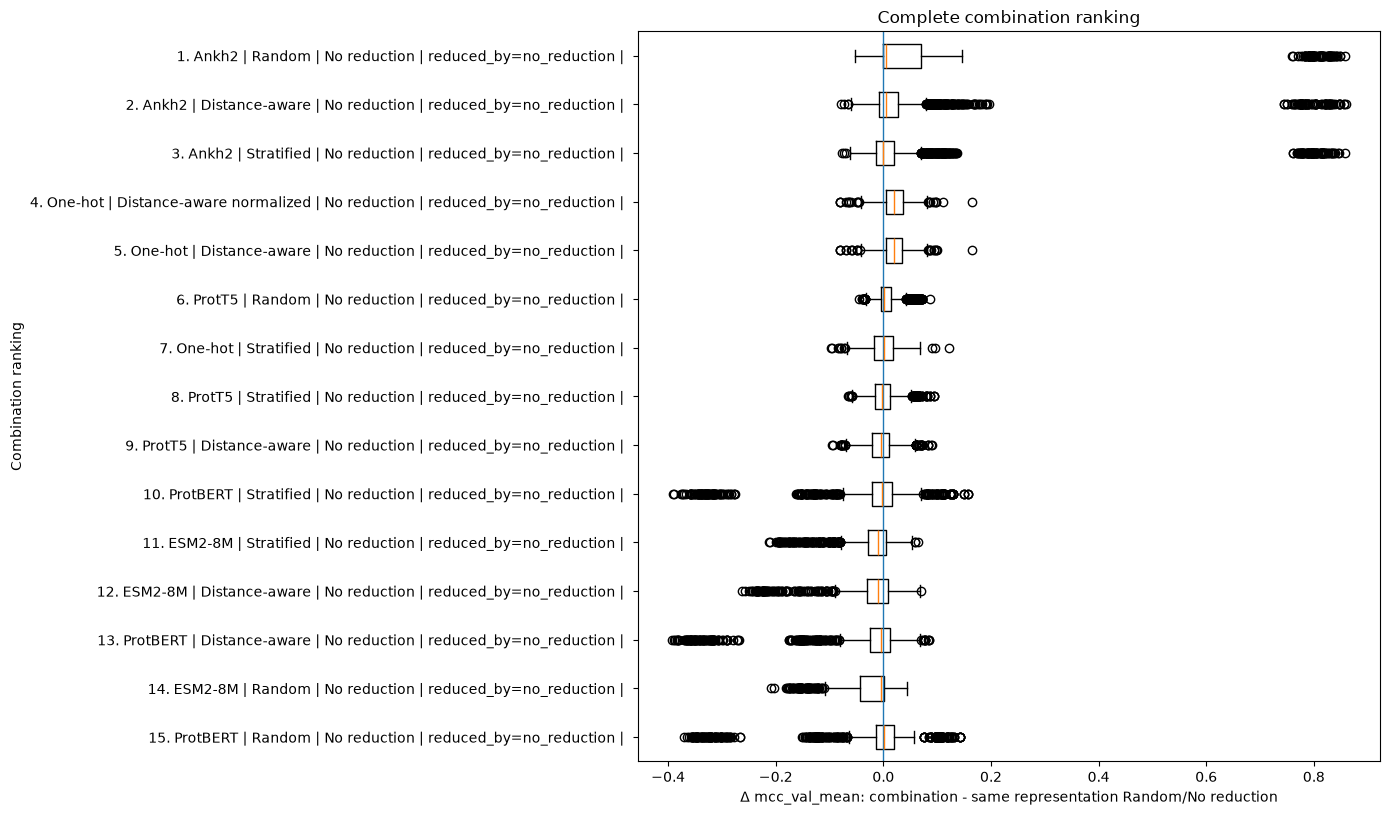

In [44]:
# %%
plot_RE_combination_ranking_boxplot(
    delta_combination=delta_combination,
    RE_combination_ranking=RE_combination_ranking,
    metric=PRIMARY_METRIC,
    top_n=15,
    rank_col="rank_by_lowest_loss",
    output_file=f"{folder_path}/RE_complete_combination_ranking_boxplot.png",
)

- Ranking of realistic combinations

In [45]:
# %%
REALISTIC_PARTITIONS = [
    "Distance-aware",
]

REALISTIC_REDUCTIONS = [
    "Distance reduction",
    "Homology reduction",
]

delta_combination_realistic = delta_combination[
    delta_combination["partition_label"].astype(str).isin(REALISTIC_PARTITIONS)
    &
    delta_combination["reduction_label"].astype(str).isin(REALISTIC_REDUCTIONS)
].copy()

print("delta_combination_realistic shape:", delta_combination_realistic.shape)

display(
    delta_combination_realistic
    .groupby(["partition_label", "reduction_label"], dropna=False)
    .size()
    .reset_index(name="n_pairs")
    .sort_values(["partition_label", "reduction_label"])
)

delta_combination_realistic shape: (607520, 61)


,partition_label,reduction_label,n_pairs
0,Distance-aware,Distance reduction,557600
1,Distance-aware,Homology reduction,49920


In [46]:
# %%
R6_group_cols = [
    "representation_label",
    "partition_label",
    "reduction_label",
    "reduced_by_label_clean",
    "scaler",
]

R6_realistic_combination_ranking = make_decision_ranking(
    delta_df=delta_combination_realistic,
    group_cols=R6_group_cols,
    primary_metric=PRIMARY_METRIC,
    secondary_metric=SECONDARY_METRIC,
    rank_context_cols=[],  # ranking único dentro de escenarios realistas
    performance_filter="median",
    min_pairs=5,
)

print("R6_realistic_combination_ranking shape:", R6_realistic_combination_ranking.shape)
display(R6_realistic_combination_ranking.head())

R6_realistic_combination_ranking shape: (91, 35)


,representation_label,partition_label,reduction_label,reduced_by_label_clean,scaler,n_pairs,n_seeds,baseline_mean__mcc_val_mean,candidate_mean__mcc_val_mean,delta_mean__mcc_val_mean,...,retention_mean__f1_val_mean,prop_negative_delta__f1_val_mean,prop_delta_below_minus_005__f1_val_mean,prop_delta_below_minus_010__f1_val_mean,performance_threshold,passes_min_pairs,passes_performance_filter,rank_by_lowest_loss,decision_rank,decision_class
0,Ankh2,Distance-aware,Distance reduction,Mistral-Prot,normalizer_l2,8352,30,0.755508,0.704108,-0.051400,...,0.858598,0.737069,0.523348,0.301245,0.242438,True,True,1,1,Recommended
1,Ankh2,Distance-aware,Distance reduction,Mistral-Prot,none,8352,30,0.755508,0.628088,-0.127419,...,0.813828,0.817050,0.610991,0.377993,0.242438,True,True,2,2,Recommended
2,ESM2-8M,Distance-aware,Distance reduction,Mistral-Prot,none,8352,30,0.820533,0.652736,-0.167798,...,0.783082,0.993534,0.813937,0.485752,0.242438,True,True,3,3,Recommended
3,ProtT5,Distance-aware,Distance reduction,Mistral-Prot,none,8352,30,0.832200,0.663749,-0.168452,...,0.784975,0.993295,0.808669,0.507304,0.242438,True,True,4,4,Recommended
4,ProtT5,Distance-aware,Distance reduction,Mistral-Prot,normalizer_l2,8352,30,0.832200,0.662349,-0.169851,...,0.780310,0.963602,0.744133,0.462763,0.242438,True,True,5,5,Recommended


In [47]:
# %%
R6_cols_to_show = [
    "representation_label",
    "partition_label",
    "reduction_label",
    "reduced_by_label_clean",
    "scaler",
    "n_pairs",
    "n_seeds",
    f"baseline_mean__{PRIMARY_METRIC}",
    f"candidate_mean__{PRIMARY_METRIC}",
    f"delta_mean__{PRIMARY_METRIC}",
    f"delta_median__{PRIMARY_METRIC}",
    f"delta_std__{PRIMARY_METRIC}",
    f"loss_mean__{PRIMARY_METRIC}",
    f"retention_mean__{PRIMARY_METRIC}",
    f"prop_negative_delta__{PRIMARY_METRIC}",
    f"prop_delta_below_minus_005__{PRIMARY_METRIC}",
    f"prop_delta_below_minus_010__{PRIMARY_METRIC}",
    "rank_by_lowest_loss",
    "decision_rank",
    "decision_class",
]

R6_cols_to_show = [
    c for c in R6_cols_to_show
    if c in R6_realistic_combination_ranking.columns
]

display(
    R6_realistic_combination_ranking[R6_cols_to_show]
    .sort_values("rank_by_lowest_loss", na_position="last")
    .head(5)
)

,representation_label,partition_label,reduction_label,reduced_by_label_clean,scaler,n_pairs,n_seeds,baseline_mean__mcc_val_mean,candidate_mean__mcc_val_mean,delta_mean__mcc_val_mean,delta_median__mcc_val_mean,delta_std__mcc_val_mean,loss_mean__mcc_val_mean,retention_mean__mcc_val_mean,prop_negative_delta__mcc_val_mean,prop_delta_below_minus_005__mcc_val_mean,prop_delta_below_minus_010__mcc_val_mean,rank_by_lowest_loss,decision_rank,decision_class
0,Ankh2,Distance-aware,Distance reduction,Mistral-Prot,normalizer_l2,8352,30,0.755508,0.704108,-0.051400,-0.044082,0.256469,0.051400,0.878363,0.703903,0.466715,0.272031,1,1,Recommended
1,Ankh2,Distance-aware,Distance reduction,Mistral-Prot,none,8352,30,0.755508,0.628088,-0.127419,-0.061516,0.195705,0.127419,0.831601,0.780172,0.559507,0.346983,2,2,Recommended
2,ESM2-8M,Distance-aware,Distance reduction,Mistral-Prot,none,8352,30,0.820533,0.652736,-0.167798,-0.090581,0.190862,0.167798,0.791949,0.981681,0.757663,0.456897,3,3,Recommended
3,ProtT5,Distance-aware,Distance reduction,Mistral-Prot,none,8352,30,0.832200,0.663749,-0.168452,-0.095695,0.191373,0.168452,0.795179,0.980603,0.767720,0.479167,4,4,Recommended
4,ProtT5,Distance-aware,Distance reduction,Mistral-Prot,normalizer_l2,8352,30,0.832200,0.662349,-0.169851,-0.082988,0.215412,0.169851,0.794919,0.937620,0.693367,0.426245,5,5,Recommended


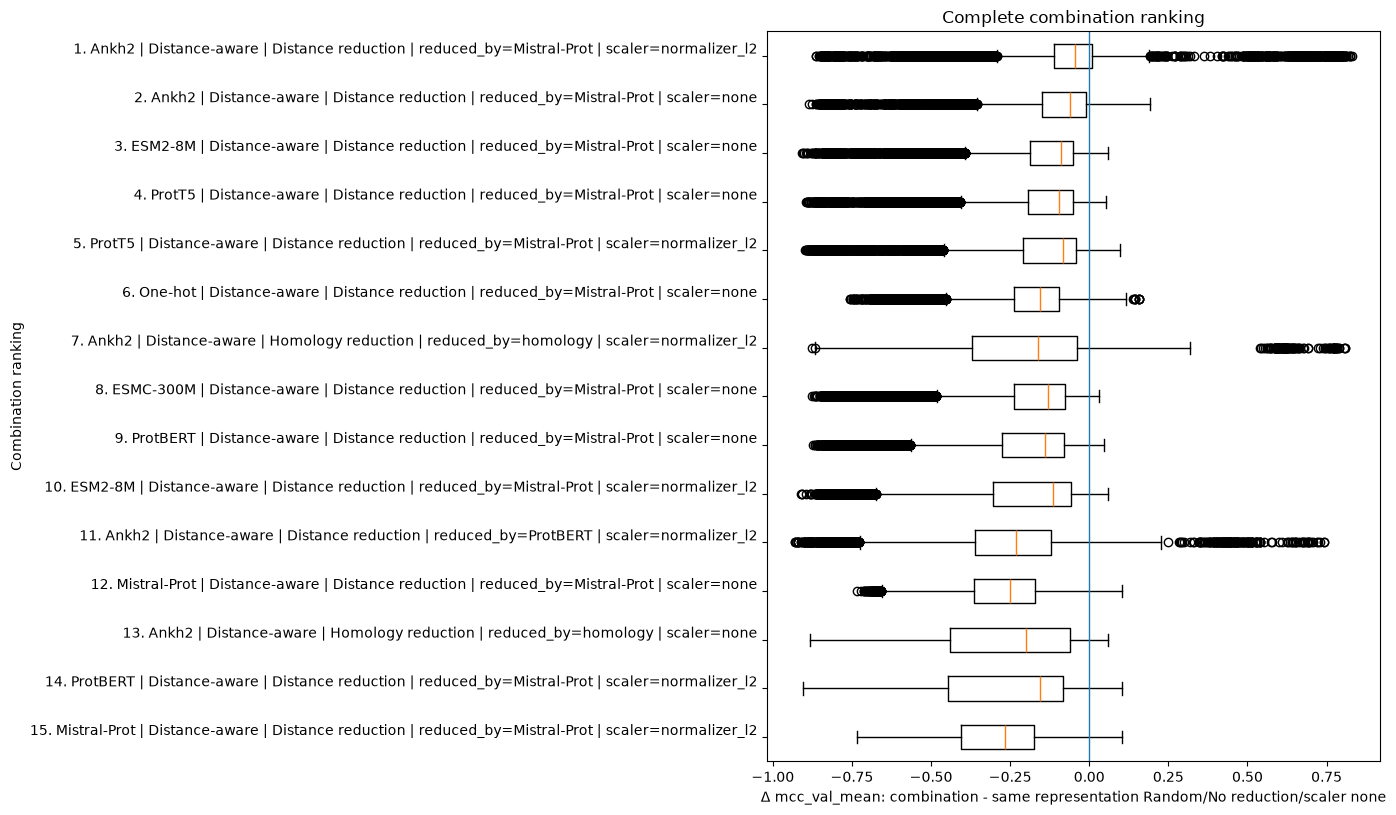

In [48]:
# %%
plot_R5_combination_ranking_boxplot(
    delta_combination=delta_combination_realistic,
    R5_combination_ranking=R6_realistic_combination_ranking,
    metric=PRIMARY_METRIC,
    top_n=15,
    rank_col="rank_by_lowest_loss",
    output_file=f"{folder_path}/R6_realistic_combination_ranking_boxplot.png",
)

In [49]:
# %%
R7_group_cols = [
    "representation_label",
    "partition_label",
    "reduction_label",
    "reduced_by_label_clean",
]

R7_realistic_ranking_collapsed_scaler = make_decision_ranking(
    delta_df=delta_combination_realistic,
    group_cols=R7_group_cols,
    primary_metric=PRIMARY_METRIC,
    secondary_metric=SECONDARY_METRIC,
    rank_context_cols=[],
    performance_filter="median",
    min_pairs=5,
)

print(
    "R7_realistic_ranking_collapsed_scaler shape:",
    R7_realistic_ranking_collapsed_scaler.shape,
)

display(R7_realistic_ranking_collapsed_scaler.head())

R7_realistic_ranking_collapsed_scaler shape: (49, 34)


,representation_label,partition_label,reduction_label,reduced_by_label_clean,n_pairs,n_seeds,baseline_mean__mcc_val_mean,candidate_mean__mcc_val_mean,delta_mean__mcc_val_mean,delta_median__mcc_val_mean,...,retention_mean__f1_val_mean,prop_negative_delta__f1_val_mean,prop_delta_below_minus_005__f1_val_mean,prop_delta_below_minus_010__f1_val_mean,performance_threshold,passes_min_pairs,passes_performance_filter,rank_by_lowest_loss,decision_rank,decision_class
0,Ankh2,Distance-aware,Distance reduction,Mistral-Prot,16704,30,0.755508,0.666098,-0.089409,-0.052078,...,0.836213,0.777059,0.567170,0.339619,0.238627,True,True,1,1,Recommended
1,ProtT5,Distance-aware,Distance reduction,Mistral-Prot,16704,30,0.832200,0.663049,-0.169151,-0.089210,...,0.782643,0.978448,0.776401,0.485034,0.238627,True,True,2,2,Recommended
2,One-hot,Distance-aware,Distance reduction,Mistral-Prot,7680,30,0.582555,0.392047,-0.190508,-0.154972,...,0.605044,0.999089,0.977865,0.876302,0.238627,True,True,3,3,Recommended
3,ESM2-8M,Distance-aware,Distance reduction,Mistral-Prot,16704,30,0.820533,0.624928,-0.195605,-0.100621,...,0.745986,0.993954,0.829143,0.531968,0.238627,True,True,4,4,Recommended
4,Ankh2,Distance-aware,Homology reduction,homology,7680,30,0.755506,0.520952,-0.234554,-0.182067,...,0.639889,0.884766,0.793750,0.664453,0.238627,True,True,5,5,Recommended


In [50]:
# %%
R7_cols_to_show = [
    "representation_label",
    "partition_label",
    "reduction_label",
    "reduced_by_label_clean",
    "n_pairs",
    "n_seeds",
    f"baseline_mean__{PRIMARY_METRIC}",
    f"candidate_mean__{PRIMARY_METRIC}",
    f"delta_mean__{PRIMARY_METRIC}",
    f"delta_median__{PRIMARY_METRIC}",
    f"delta_std__{PRIMARY_METRIC}",
    f"loss_mean__{PRIMARY_METRIC}",
    f"retention_mean__{PRIMARY_METRIC}",
    f"prop_negative_delta__{PRIMARY_METRIC}",
    f"prop_delta_below_minus_005__{PRIMARY_METRIC}",
    f"prop_delta_below_minus_010__{PRIMARY_METRIC}",
    "rank_by_lowest_loss",
    "decision_rank",
    "decision_class",
]

R7_cols_to_show = [
    c for c in R7_cols_to_show
    if c in R7_realistic_ranking_collapsed_scaler.columns
]

display(
    R7_realistic_ranking_collapsed_scaler[R7_cols_to_show]
    .sort_values("rank_by_lowest_loss", na_position="last")
    .head(5)
)

,representation_label,partition_label,reduction_label,reduced_by_label_clean,n_pairs,n_seeds,baseline_mean__mcc_val_mean,candidate_mean__mcc_val_mean,delta_mean__mcc_val_mean,delta_median__mcc_val_mean,delta_std__mcc_val_mean,loss_mean__mcc_val_mean,retention_mean__mcc_val_mean,prop_negative_delta__mcc_val_mean,prop_delta_below_minus_005__mcc_val_mean,prop_delta_below_minus_010__mcc_val_mean,rank_by_lowest_loss,decision_rank,decision_class
0,Ankh2,Distance-aware,Distance reduction,Mistral-Prot,16704,30,0.755508,0.666098,-0.089409,-0.052078,0.231258,0.089409,0.854982,0.742038,0.513111,0.309507,1,1,Recommended
1,ProtT5,Distance-aware,Distance reduction,Mistral-Prot,16704,30,0.832200,0.663049,-0.169151,-0.089210,0.203743,0.169151,0.795049,0.959112,0.730544,0.452706,2,2,Recommended
2,One-hot,Distance-aware,Distance reduction,Mistral-Prot,7680,30,0.582555,0.392047,-0.190508,-0.154972,0.148394,0.190508,0.663143,0.968359,0.899349,0.733203,3,3,Recommended
3,ESM2-8M,Distance-aware,Distance reduction,Mistral-Prot,16704,30,0.820533,0.624928,-0.195605,-0.100621,0.218349,0.195605,0.757595,0.982399,0.777179,0.502155,4,4,Recommended
4,Ankh2,Distance-aware,Homology reduction,homology,7680,30,0.755506,0.520952,-0.234554,-0.182067,0.260571,0.234554,0.673797,0.866406,0.752865,0.630599,5,5,Recommended


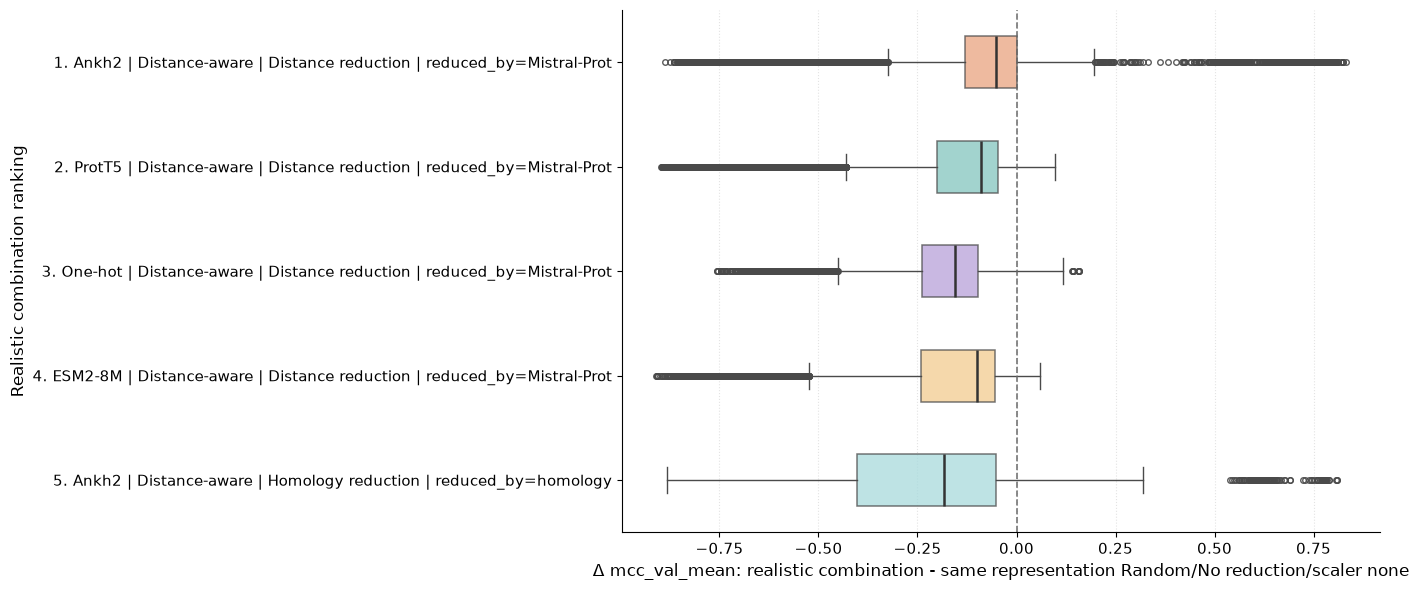

In [51]:
plot_R7_realistic_ranking_collapsed_scaler_boxplot_pretty(
    delta_combination_realistic=delta_combination_realistic,
    R7_ranking=R7_realistic_ranking_collapsed_scaler,
    metric=PRIMARY_METRIC,
    top_n=5,
    rank_col="rank_by_lowest_loss",
    output_file="R7_realistic_ranking_collapsed_scaler_boxplot.png",
)

In [52]:
outliers_R7 = get_R7_boxplot_outliers(
    delta_combination_realistic=delta_combination_realistic,
    R7_ranking=R7_realistic_ranking_collapsed_scaler,
    metric=PRIMARY_METRIC,
    top_n=5,
    rank_col="rank_by_lowest_loss",
)

In [53]:
DELTA_PRIMARY_COLUMN = f"delta__{PRIMARY_METRIC}"

cols_to_show = [
    "rank",
    "combo_label",
    "outlier_type",
    DELTA_PRIMARY_COLUMN,
    "__original_index",
]

extra_cols = [
    "model_label",
    "scaler_label",
    "seed",
    "split_seed",
    "cv_k",
    "representation_label",
    "partition_label",
    "reduction_label",
    "reduced_by_label_clean",
]

cols_to_show = [
    col for col in cols_to_show + extra_cols
    if col in outliers_R7.columns
]

outliers_R7[cols_to_show].sort_values(
    ["rank", "outlier_type", DELTA_PRIMARY_COLUMN]
)

,rank,combo_label,outlier_type,delta__mcc_val_mean,__original_index,seed,representation_label,partition_label,reduction_label,reduced_by_label_clean
535,1,1. Ankh2 | Distance-aware | Distance reduction...,alto,0.197346,82447,2778,Ankh2,Distance-aware,Distance reduction,Mistral-Prot
574,1,1. Ankh2 | Distance-aware | Distance reduction...,alto,0.198882,94182,5674,Ankh2,Distance-aware,Distance reduction,Mistral-Prot
1111,1,1. Ankh2 | Distance-aware | Distance reduction...,alto,0.202209,142842,90,Ankh2,Distance-aware,Distance reduction,Mistral-Prot
753,1,1. Ankh2 | Distance-aware | Distance reduction...,alto,0.202474,123618,8555,Ankh2,Distance-aware,Distance reduction,Mistral-Prot
673,1,1. Ankh2 | Distance-aware | Distance reduction...,alto,0.205538,119111,4367,Ankh2,Distance-aware,Distance reduction,Mistral-Prot
...,...,...,...,...,...,...,...,...,...,...
6996,5,5. Ankh2 | Distance-aware | Homology reduction...,alto,0.789032,236088,3875,Ankh2,Distance-aware,Homology reduction,homology
7024,5,5. Ankh2 | Distance-aware | Homology reduction...,alto,0.789309,240302,7209,Ankh2,Distance-aware,Homology reduction,homology
7038,5,5. Ankh2 | Distance-aware | Homology reduction...,alto,0.806139,242393,9004,Ankh2,Distance-aware,Homology reduction,homology
7040,5,5. Ankh2 | Distance-aware | Homology reduction...,alto,0.808839,242698,9177,Ankh2,Distance-aware,Homology reduction,homology


- R8. Realistic ranking considering algorithm

In [54]:
# %%
R8_group_cols = [
    "representation_label",
    "partition_label",
    "reduction_label",
    "reduced_by_label_clean",
    "algorithm",
]

R8_realistic_ranking_with_algorithm = make_decision_ranking(
    delta_df=delta_combination_realistic,
    group_cols=R8_group_cols,
    primary_metric=PRIMARY_METRIC,
    secondary_metric=SECONDARY_METRIC,
    rank_context_cols=[],  # ranking único global
    performance_filter="median",
    min_pairs=5,
)

print(
    "R8_realistic_ranking_with_algorithm shape:",
    R8_realistic_ranking_with_algorithm.shape,
)

display(R8_realistic_ranking_with_algorithm.head())

R8_realistic_ranking_with_algorithm shape: (343, 35)


,representation_label,partition_label,reduction_label,reduced_by_label_clean,algorithm,n_pairs,n_seeds,baseline_mean__mcc_val_mean,candidate_mean__mcc_val_mean,delta_mean__mcc_val_mean,...,retention_mean__f1_val_mean,prop_negative_delta__f1_val_mean,prop_delta_below_minus_005__f1_val_mean,prop_delta_below_minus_010__f1_val_mean,performance_threshold,passes_min_pairs,passes_performance_filter,rank_by_lowest_loss,decision_rank,decision_class
0,Ankh2,Distance-aware,Distance reduction,Mistral-Prot,KNeighborsClassifier,2610,30,0.745900,0.744066,-0.001834,...,0.951257,0.419157,0.247126,0.192337,0.223145,True,True,1,1,Recommended
1,Ankh2,Distance-aware,Distance reduction,Mistral-Prot,LogisticRegression,2088,30,0.398526,0.366663,-0.031862,...,0.647231,0.396552,0.341954,0.323276,0.223145,True,True,2,2,Recommended
2,Mistral-Prot,Distance-aware,Distance reduction,Mistral-Prot,GaussianNB,1566,30,0.288151,0.240051,-0.048100,...,0.738293,0.996169,0.931034,0.534483,0.223145,True,True,3,3,Recommended
3,Ankh2,Distance-aware,Distance reduction,Mistral-Prot,SVC,2610,30,0.698204,0.645434,-0.052770,...,0.821404,0.738314,0.462835,0.264368,0.223145,True,True,4,4,Recommended
4,Ankh2,Distance-aware,Distance reduction,Mistral-Prot,GaussianNB,1566,30,0.826290,0.770283,-0.056006,...,0.909855,0.854406,0.446360,0.230524,0.223145,True,True,5,5,Recommended


In [55]:
# %%
R8_cols_to_show = [
    "representation_label",
    "partition_label",
    "reduction_label",
    "reduced_by_label_clean",
    "algorithm",
    "n_pairs",
    "n_seeds",
    f"baseline_mean__{PRIMARY_METRIC}",
    f"candidate_mean__{PRIMARY_METRIC}",
    f"delta_mean__{PRIMARY_METRIC}",
    f"delta_median__{PRIMARY_METRIC}",
    f"delta_std__{PRIMARY_METRIC}",
    f"loss_mean__{PRIMARY_METRIC}",
    f"retention_mean__{PRIMARY_METRIC}",
    f"prop_negative_delta__{PRIMARY_METRIC}",
    f"prop_delta_below_minus_005__{PRIMARY_METRIC}",
    f"prop_delta_below_minus_010__{PRIMARY_METRIC}",
    "rank_by_lowest_loss",
    "decision_rank",
    "decision_class",
]

R8_cols_to_show = [
    c for c in R8_cols_to_show
    if c in R8_realistic_ranking_with_algorithm.columns
]

display(
    R8_realistic_ranking_with_algorithm[R8_cols_to_show]
    .sort_values("rank_by_lowest_loss", na_position="last")
    .head(5)
)

,representation_label,partition_label,reduction_label,reduced_by_label_clean,algorithm,n_pairs,n_seeds,baseline_mean__mcc_val_mean,candidate_mean__mcc_val_mean,delta_mean__mcc_val_mean,delta_median__mcc_val_mean,delta_std__mcc_val_mean,loss_mean__mcc_val_mean,retention_mean__mcc_val_mean,prop_negative_delta__mcc_val_mean,prop_delta_below_minus_005__mcc_val_mean,prop_delta_below_minus_010__mcc_val_mean,rank_by_lowest_loss,decision_rank,decision_class
0,Ankh2,Distance-aware,Distance reduction,Mistral-Prot,KNeighborsClassifier,2610,30,0.745900,0.744066,-0.001834,0.042898,0.146493,0.001834,0.998527,0.314176,0.193870,0.152490,1,1,Recommended
1,Ankh2,Distance-aware,Distance reduction,Mistral-Prot,LogisticRegression,2088,30,0.398526,0.366663,-0.031862,0.000000,0.367444,0.031862,0.680623,0.370690,0.328544,0.309387,2,2,Recommended
2,Mistral-Prot,Distance-aware,Distance reduction,Mistral-Prot,GaussianNB,1566,30,0.288151,0.240051,-0.048100,-0.040438,0.065325,0.048100,0.838745,0.783525,0.400383,0.166667,3,3,Recommended
3,Ankh2,Distance-aware,Distance reduction,Mistral-Prot,SVC,2610,30,0.698204,0.645434,-0.052770,-0.037960,0.312776,0.052770,0.837081,0.714559,0.414559,0.230268,4,4,Recommended
4,Ankh2,Distance-aware,Distance reduction,Mistral-Prot,GaussianNB,1566,30,0.826290,0.770283,-0.056006,-0.028093,0.103169,0.056006,0.932422,0.761175,0.324393,0.183269,5,5,Recommended


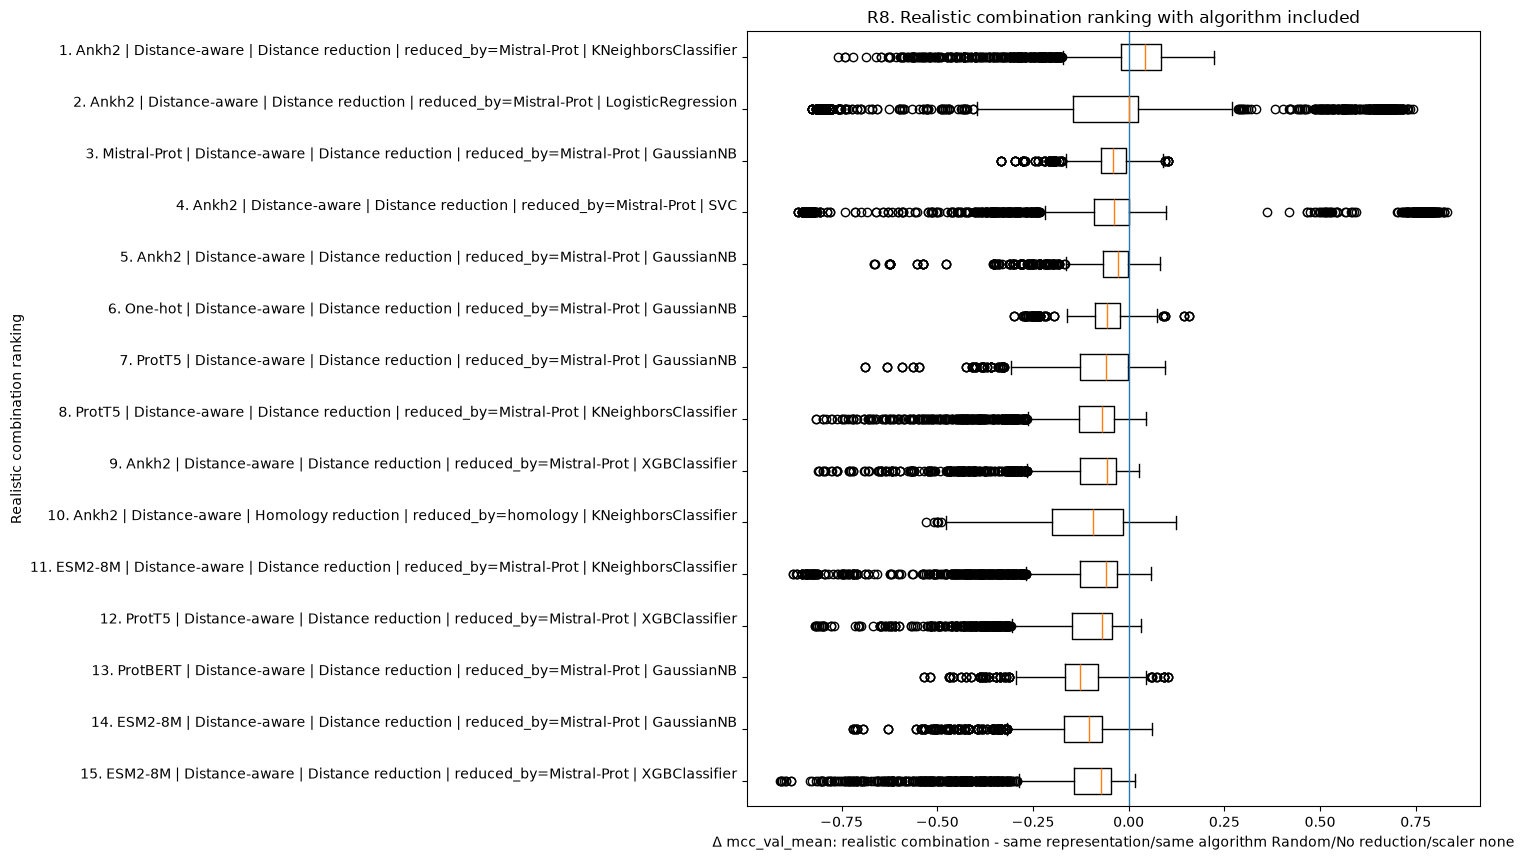

In [56]:
# %%
plot_R8_realistic_ranking_with_algorithm_boxplot(
    delta_combination_realistic=delta_combination_realistic,
    R8_ranking=R8_realistic_ranking_with_algorithm,
    metric=PRIMARY_METRIC,
    top_n=15,
    rank_col="rank_by_lowest_loss",
    output_file=f"{folder_path}/R8_realistic_ranking_with_algorithm_boxplot.png",
)

- What do the top positions in the rankings have in common?

In [57]:
# %%
R7_top_patterns = summarize_top_ranked_patterns(
    ranking_df=R7_realistic_ranking_collapsed_scaler,
    feature_cols=[
        "representation_label",
        "partition_label",
        "reduction_label",
        "reduced_by_label_clean",
    ],
    top_n=100,
    rank_col="rank_by_lowest_loss",
)

display(R7_top_patterns)

,feature,value,top_count,top_fraction,all_count,all_fraction,enrichment
0,partition_label,Distance-aware,49,1.000000,49,1.000000,1.0
1,reduced_by_label_clean,Mistral-Prot,7,0.142857,7,0.142857,1.0
2,reduced_by_label_clean,homology,7,0.142857,7,0.142857,1.0
3,reduced_by_label_clean,ProtBERT,7,0.142857,7,0.142857,1.0
4,reduced_by_label_clean,ESM2-8M,7,0.142857,7,0.142857,1.0
5,reduced_by_label_clean,ProtT5,7,0.142857,7,0.142857,1.0
6,reduced_by_label_clean,Ankh2,7,0.142857,7,0.142857,1.0
7,reduced_by_label_clean,ESMC-300M,7,0.142857,7,0.142857,1.0
8,reduction_label,Distance reduction,42,0.857143,42,0.857143,1.0
9,reduction_label,Homology reduction,7,0.142857,7,0.142857,1.0


In [58]:
# %%
R8_top_patterns = summarize_top_ranked_patterns(
    ranking_df=R8_realistic_ranking_with_algorithm,
    feature_cols=[
        "representation_label",
        "partition_label",
        "reduction_label",
        "reduced_by_label_clean",
        "algorithm",
    ],
    top_n=100,
    rank_col="rank_by_lowest_loss",
)

display(R8_top_patterns)

,feature,value,top_count,top_fraction,all_count,all_fraction,enrichment
0,algorithm,GaussianNB,31,0.31,49,0.142857,2.17
1,algorithm,KNeighborsClassifier,14,0.14,49,0.142857,0.98
2,algorithm,SVC,13,0.13,49,0.142857,0.91
3,algorithm,XGBClassifier,13,0.13,49,0.142857,0.91
4,algorithm,DecisionTreeClassifier,12,0.12,49,0.142857,0.84
5,algorithm,LogisticRegression,9,0.09,49,0.142857,0.63
6,algorithm,RandomForestClassifier,8,0.08,49,0.142857,0.56
7,partition_label,Distance-aware,100,1.00,343,1.000000,1.00
8,reduced_by_label_clean,Mistral-Prot,42,0.42,49,0.142857,2.94
9,reduced_by_label_clean,ProtBERT,18,0.18,49,0.142857,1.26


In [59]:
OUTDIR = Path(folder_path)
OUTDIR.mkdir(parents=True, exist_ok=True)

# 1. Copy original enrichment table
R8_top_patterns_formatted = R8_top_patterns.copy()

# 2. Rename feature names for clearer presentation
feature_name_map = {
    "algorithm": "Algorithm",
    "partition_label": "Partition",
    "reduction_label": "Reduction strategy",
    "reduced_by_label_clean": "Reduced by",
    "representation_label": "Training representation",
}

R8_top_patterns_formatted["Feature"] = (
    R8_top_patterns_formatted["feature"]
    .map(feature_name_map)
    .fillna(R8_top_patterns_formatted["feature"])
)

# 3. Create percentage columns
R8_top_patterns_formatted["Top (%)"] = (
    R8_top_patterns_formatted["top_fraction"] * 100
).round(1)

R8_top_patterns_formatted["Global (%)"] = (
    R8_top_patterns_formatted["all_fraction"] * 100
).round(1)

R8_top_patterns_formatted["Enrichment"] = (
    R8_top_patterns_formatted["enrichment"]
).round(2)

# 4. Rename count/value columns
R8_top_patterns_formatted = R8_top_patterns_formatted.rename(
    columns={
        "value": "Value",
        "top_count": "Top count",
        "all_count": "Global count",
    }
)

# 5. Keep only columns useful for presentation
R8_top_patterns_formatted = R8_top_patterns_formatted[
    [
        "Feature",
        "Value",
        "Top count",
        "Top (%)",
        "Global count",
        "Global (%)",
        "Enrichment",
    ]
]

# 6. Optional: sort by enrichment, but keeping high-frequency factors visible
R8_top_patterns_formatted = R8_top_patterns_formatted.sort_values(
    ["Feature", "Enrichment", "Top (%)"],
    ascending=[True, False, False],
).reset_index(drop=True)

display(R8_top_patterns_formatted)

,Feature,Value,Top count,Top (%),Global count,Global (%),Enrichment
0,Algorithm,GaussianNB,31,31.0,49,14.3,2.17
1,Algorithm,KNeighborsClassifier,14,14.0,49,14.3,0.98
2,Algorithm,SVC,13,13.0,49,14.3,0.91
3,Algorithm,XGBClassifier,13,13.0,49,14.3,0.91
4,Algorithm,DecisionTreeClassifier,12,12.0,49,14.3,0.84
5,Algorithm,LogisticRegression,9,9.0,49,14.3,0.63
6,Algorithm,RandomForestClassifier,8,8.0,49,14.3,0.56
7,Partition,Distance-aware,100,100.0,343,100.0,1.00
8,Reduced by,Mistral-Prot,42,42.0,49,14.3,2.94
9,Reduced by,ProtBERT,18,18.0,49,14.3,1.26


- Pairwise comparisons between top configurations

In [60]:
R7_group_cols = [
    "representation_label",
    "partition_label",
    "reduction_label",
    "reduced_by_label_clean",
]

R7_pair_cols = [
    "algorithm",
    "scaler",
    "cfg_idx",
    "seed",
    "reduction_level_label_clean",
]

In [61]:
delta_R7_distance = delta_combination_realistic[
    delta_combination_realistic["reduction_label"].astype(str).eq("Distance reduction")
].copy()

R7_ranking_distance = R7_realistic_ranking_collapsed_scaler[
    R7_realistic_ranking_collapsed_scaler["reduction_label"].astype(str).eq("Distance reduction")
].copy()

R7_pairwise_top = paired_compare_top_configs(
    delta_df=delta_R7_distance,
    ranking_df=R7_ranking_distance,
    group_cols=R7_group_cols,
    pair_cols=R7_pair_cols,
    metric=PRIMARY_METRIC,
    top_n=15,
    rank_col="rank_by_lowest_loss",
    n_boot=2000,
    ci=95,
    random_state=123,
)

In [62]:
R8_group_cols = [
    "representation_label",
    "partition_label",
    "reduction_label",
    "reduced_by_label_clean",
    "algorithm",
]

R8_pair_cols = [
    "scaler",
    "cfg_idx",
    "seed",
    "reduction_level_label_clean",
]

delta_R8_distance = delta_combination_realistic[
    delta_combination_realistic["reduction_label"].astype(str).eq("Distance reduction")
].copy()

R8_ranking_distance = R8_realistic_ranking_with_algorithm[
    R8_realistic_ranking_with_algorithm["reduction_label"].astype(str).eq("Distance reduction")
].copy()

R8_pairwise_top = paired_compare_top_configs(
    delta_df=delta_R8_distance,
    ranking_df=R8_ranking_distance,
    group_cols=R8_group_cols,
    pair_cols=R8_pair_cols,
    metric=PRIMARY_METRIC,
    top_n=15,
    rank_col="rank_by_lowest_loss",
    n_boot=2000,
    ci=95,
    random_state=123,
)

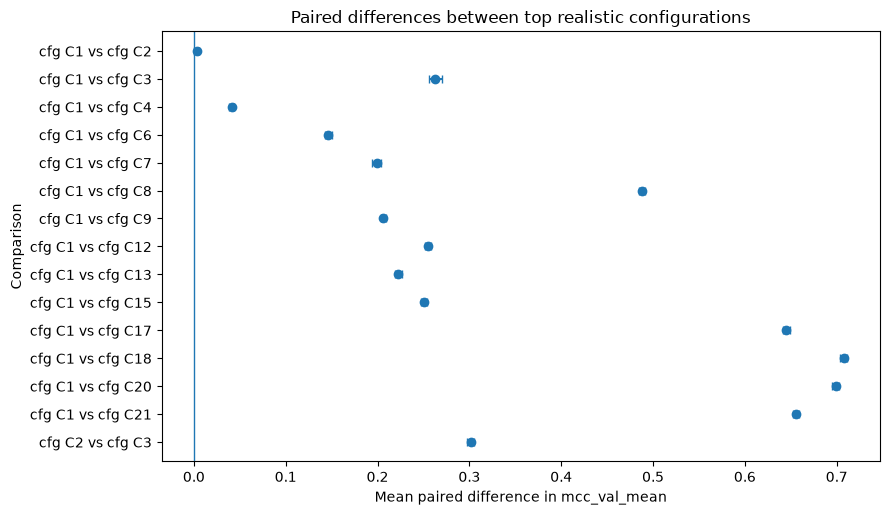

In [63]:
plot_pairwise_config_differences(
    pairwise_df=R7_pairwise_top,
    metric=PRIMARY_METRIC,
    top_n=15,
    title="Paired differences between top realistic configurations",
    output_file=f"{folder_path}/R7_pairwise_top_config_differences.png",
)

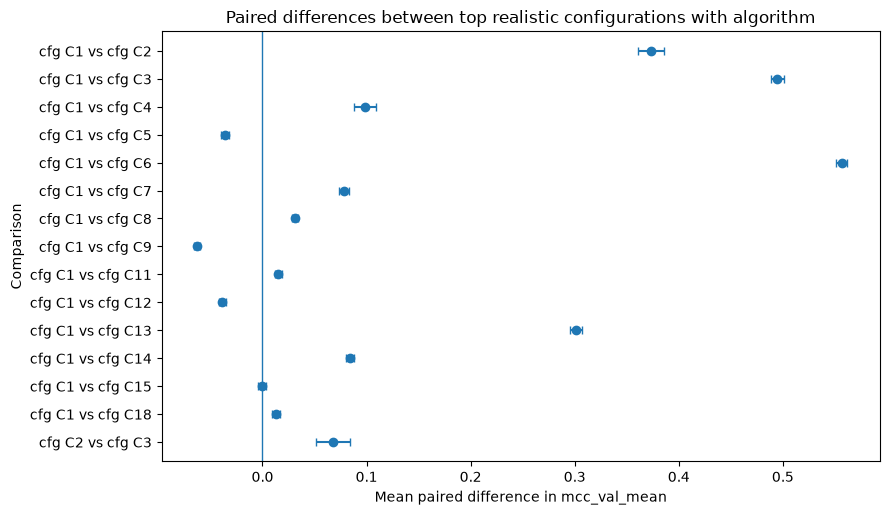

In [64]:
plot_pairwise_config_differences(
    pairwise_df=R8_pairwise_top,
    metric=PRIMARY_METRIC,
    top_n=15,
    title="Paired differences between top realistic configurations with algorithm",
    output_file=f"{folder_path}/R8_pairwise_top_config_differences.png",
)

- Analyze the top percentage of the ranking

In [65]:
R8_feature_cols = [
    "representation_label",
    "partition_label",
    "reduction_label",
    "reduced_by_label_clean",
    "algorithm",
]

top_fractions = [0.05, 0.10, 0.20, 0.30]

R8_percentile_patterns_list = []

for frac in top_fractions:
    tmp = summarize_top_ranked_patterns_by_percentile(
        ranking_df=R8_realistic_ranking_with_algorithm,
        feature_cols=R8_feature_cols,
        top_fraction=frac,
        rank_col="rank_by_lowest_loss",
        min_top_n=5,
    )

    R8_percentile_patterns_list.append(tmp)

R8_percentile_patterns = pd.concat(
    R8_percentile_patterns_list,
    ignore_index=True,
)

display(R8_percentile_patterns)

,feature,value,top_count,top_fraction,all_count,all_fraction,enrichment,top_fraction_cutoff,top_percentile_label,n_ranked_total,top_n_used,rank_cutoff
0,algorithm,GaussianNB,8,0.444444,49,0.142857,3.111111,0.05,Top 5%,343,18,18
1,algorithm,KNeighborsClassifier,4,0.222222,49,0.142857,1.555556,0.05,Top 5%,343,18,18
2,algorithm,XGBClassifier,3,0.166667,49,0.142857,1.166667,0.05,Top 5%,343,18,18
3,algorithm,LogisticRegression,1,0.055556,49,0.142857,0.388889,0.05,Top 5%,343,18,18
4,algorithm,SVC,1,0.055556,49,0.142857,0.388889,0.05,Top 5%,343,18,18
...,...,...,...,...,...,...,...,...,...,...,...,...
81,representation_label,One-hot,13,0.126214,49,0.142857,0.883495,0.30,Top 30%,343,103,103
82,representation_label,ProtT5,13,0.126214,49,0.142857,0.883495,0.30,Top 30%,343,103,103
83,representation_label,ESM2-8M,13,0.126214,49,0.142857,0.883495,0.30,Top 30%,343,103,103
84,representation_label,ESMC-300M,9,0.087379,49,0.142857,0.611650,0.30,Top 30%,343,103,103
